<a href="https://colab.research.google.com/github/Sshahsavar/COPULA-MODELS/blob/main/COPULA_report_educational.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Load Data and data clearing


## 10 industry returns

Data source:

https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/Data_Library/det_10_ind_port.html

In [40]:
import pandas as pd
import io

def split_returns_file(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()

    # Find the exact row number (0-indexed) where the 'Equal Weighted' section starts
    split_row_idx = -1
    for i, line in enumerate(lines):
        if "Average Equal Weighted Returns -- Daily" in line:
            split_row_idx = i
            break

    if split_row_idx == -1:
        raise ValueError("Could not find 'Average Equal Weighted Returns -- Daily' marker in the file.")

    # For Fama-French data, the Value Weighted section usually starts after a few metadata lines.
    # A common pattern is that the header for the value-weighted data is around line 10 (0-indexed 9).
    # The error 'Expected 1 fields in line 10, saw 11' strongly suggests line 10 is indeed the header.
    vw_header_line_num = 9 # 0-indexed line number where the VW header is located

    # Read the Value Weighted Returns (Top Part)
    # Skip lines before the header (vw_header_line_num lines) and read up to the split marker.
    # The 'header=0' means the first line after skipping is the header.
    # 'nrows' should be the number of data rows + 1 for the header, after skipping initial lines.
    df_value_weighted = pd.read_csv(
        file_path,
        skiprows=vw_header_line_num,
        nrows=split_row_idx - vw_header_line_num - 2 ,
        header=0
    )

    # Clean up empty rows if any exist at the bottom of the value-weighted section
    df_value_weighted.dropna(how='all', inplace=True)

    # Read the Equal Weighted Returns (Bottom Part)
    # Skip all lines up to and including the 'Average Equal Weighted Returns' marker.
    # The header for EW data is usually immediately after this marker.
    df_equal_weighted = pd.read_csv(
        file_path,
        skiprows=split_row_idx + 1, # Skip the marker line itself and all lines before it
        header=0 # The first line after skipping is the header for EW data
    )

    # Clean up empty rows if any exist at the bottom of the equal-weighted section
    df_equal_weighted.dropna(how='all', inplace=True)
    #drop the last line of each data frame
    df_equal_weighted = df_equal_weighted.iloc[:-1]
    df_value_weighted = df_value_weighted.iloc[:-1]
    return df_value_weighted, df_equal_weighted

# --- How to use it ---
df_vw, df_ew = split_returns_file("/content/drive/MyDrive/Back up 6 may/Econ 5990/Python notebook/10_Industry_Portfolios_Daily 2.csv")

print("Value Weighted DataFrame head:")
display(df_vw.head())
print("\nEqual Weighted DataFrame head:")
display(df_ew.head())

Value Weighted DataFrame head:


,Unnamed: 0,NoDur,Durbl,Manuf,Enrgy,HiTec,Telcm,Shops,Hlth,Utils,Other
0,19260701,0.02,-0.28,-0.23,0.57,-0.21,-0.02,-0.01,0.97,0.61,0.20
1,19260702,0.29,1.07,0.81,0.64,0.36,0.26,0.01,0.13,0.47,0.10
2,19260706,0.24,0.72,0.22,0.17,0.47,0.17,-0.23,0.23,0.73,-0.18
3,19260707,0.27,0.06,0.23,-0.04,-0.10,0.32,-0.59,0.33,0.17,0.16
4,19260708,0.69,0.05,0.15,0.12,0.35,0.40,-0.36,0.91,-0.20,0.39



Equal Weighted DataFrame head:


,Unnamed: 0,NoDur,Durbl,Manuf,Enrgy,HiTec,Telcm,Shops,Hlth,Utils,Other
0,19260701,0.37,-0.20,-0.19,0.58,-0.06,-0.06,-0.06,1.43,0.01,0.36
1,19260702,-0.01,1.00,0.68,0.46,-0.26,0.37,-0.17,0.08,0.55,-0.36
2,19260706,0.02,0.35,0.18,-0.01,0.25,0.04,0.12,0.51,0.56,0.20
3,19260707,-0.29,-0.09,0.22,-0.33,0.57,-0.33,-0.86,0.55,0.07,-0.12
4,19260708,0.91,0.27,0.69,0.51,0.52,0.87,-0.11,0.66,0.03,-0.08


In [41]:

# i use Value Weighted Data
raw = df_vw
display(raw.head())
display(raw.tail())

,Unnamed: 0,NoDur,Durbl,Manuf,Enrgy,HiTec,Telcm,Shops,Hlth,Utils,Other
0,19260701,0.02,-0.28,-0.23,0.57,-0.21,-0.02,-0.01,0.97,0.61,0.20
1,19260702,0.29,1.07,0.81,0.64,0.36,0.26,0.01,0.13,0.47,0.10
2,19260706,0.24,0.72,0.22,0.17,0.47,0.17,-0.23,0.23,0.73,-0.18
3,19260707,0.27,0.06,0.23,-0.04,-0.10,0.32,-0.59,0.33,0.17,0.16
4,19260708,0.69,0.05,0.15,0.12,0.35,0.40,-0.36,0.91,-0.20,0.39


,Unnamed: 0,NoDur,Durbl,Manuf,Enrgy,HiTec,Telcm,Shops,Hlth,Utils,Other
26228,20260424,-0.46,0.45,-0.06,-0.49,2.09,-3.57,0.83,-1.59,0.12,-0.42
26229,20260427,-1.14,0.50,-0.22,0.05,0.59,-1.00,-1.06,-0.74,-0.09,0.40
26230,20260428,1.81,-0.97,-1.06,1.59,-1.07,0.53,-0.48,-0.29,0.50,-0.10
26231,20260429,-0.30,-0.97,-0.76,2.76,-0.01,0.08,0.36,-1.09,-1.01,-0.22
26232,20260430,1.47,1.96,2.56,0.30,0.51,1.48,1.46,2.78,2.63,0.90


In [42]:
#changing the Date format to pd formart
raw = raw.rename(columns={'Unnamed: 0': 'Date'})
raw['Date'] = pd.to_datetime(raw['Date'], format='%Y%m%d', errors='coerce')
raw = raw.dropna(subset=['Date'])
display(raw.head())

,Date,NoDur,Durbl,Manuf,Enrgy,HiTec,Telcm,Shops,Hlth,Utils,Other
0,1926-07-01,0.02,-0.28,-0.23,0.57,-0.21,-0.02,-0.01,0.97,0.61,0.20
1,1926-07-02,0.29,1.07,0.81,0.64,0.36,0.26,0.01,0.13,0.47,0.10
2,1926-07-06,0.24,0.72,0.22,0.17,0.47,0.17,-0.23,0.23,0.73,-0.18
3,1926-07-07,0.27,0.06,0.23,-0.04,-0.10,0.32,-0.59,0.33,0.17,0.16
4,1926-07-08,0.69,0.05,0.15,0.12,0.35,0.40,-0.36,0.91,-0.20,0.39


## adding the Market Risk primume:

Data source:
https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/Data_Library/f-f_factors.html

In [43]:
file_path = '/content/drive/MyDrive/Back up 6 may/Econ 5990/Python notebook/F-F_Research_Data_Factors_daily.csv'

# Load the CSV, skipping the first 3 rows
df_factors = pd.read_csv(file_path, skiprows=3)

# Drop the last row
df_factors = df_factors.iloc[:-1]

display(df_factors.head())
display(df_factors.tail())

,Unnamed: 0,Mkt-RF,SMB,HML,RF
0,19260701,0.09,-0.25,-0.27,0.01
1,19260702,0.45,-0.33,-0.06,0.01
2,19260706,0.17,0.30,-0.39,0.01
3,19260707,0.09,-0.58,0.02,0.01
4,19260708,0.22,-0.38,0.19,0.01


,Unnamed: 0,Mkt-RF,SMB,HML,RF
26228,20260424,0.70,-0.34,-0.28,0.01
26229,20260427,0.10,-0.19,0.62,0.01
26230,20260428,-0.57,-0.44,0.88,0.01
26231,20260429,-0.13,-1.48,0.53,0.01
26232,20260430,1.13,0.98,-0.71,0.01


In [44]:

# Rename 'Unnamed: 0' to 'Date' in df_factors
df_factors = df_factors.rename(columns={'Unnamed: 0': 'Date'})

# Convert the 'Date' column in df_factors to datetime objects
df_factors['Date'] = pd.to_datetime(df_factors['Date'], format='%Y%m%d', errors='coerce')

# Drop any rows where Date conversion failed (if any)
df_factors.dropna(subset=['Date'], inplace=True)

# Merge df_factors and df_vw on the 'Date' column
raw = pd.merge(raw, df_factors, on='Date', how='inner')

display(raw.head())
display(raw.tail())

,Date,NoDur,Durbl,Manuf,Enrgy,HiTec,Telcm,Shops,Hlth,Utils,Other,Mkt-RF,SMB,HML,RF
0,1926-07-01,0.02,-0.28,-0.23,0.57,-0.21,-0.02,-0.01,0.97,0.61,0.20,0.09,-0.25,-0.27,0.01
1,1926-07-02,0.29,1.07,0.81,0.64,0.36,0.26,0.01,0.13,0.47,0.10,0.45,-0.33,-0.06,0.01
2,1926-07-06,0.24,0.72,0.22,0.17,0.47,0.17,-0.23,0.23,0.73,-0.18,0.17,0.30,-0.39,0.01
3,1926-07-07,0.27,0.06,0.23,-0.04,-0.10,0.32,-0.59,0.33,0.17,0.16,0.09,-0.58,0.02,0.01
4,1926-07-08,0.69,0.05,0.15,0.12,0.35,0.40,-0.36,0.91,-0.20,0.39,0.22,-0.38,0.19,0.01


,Date,NoDur,Durbl,Manuf,Enrgy,HiTec,Telcm,Shops,Hlth,Utils,Other,Mkt-RF,SMB,HML,RF
26228,2026-04-24,-0.46,0.45,-0.06,-0.49,2.09,-3.57,0.83,-1.59,0.12,-0.42,0.70,-0.34,-0.28,0.01
26229,2026-04-27,-1.14,0.50,-0.22,0.05,0.59,-1.00,-1.06,-0.74,-0.09,0.40,0.10,-0.19,0.62,0.01
26230,2026-04-28,1.81,-0.97,-1.06,1.59,-1.07,0.53,-0.48,-0.29,0.50,-0.10,-0.57,-0.44,0.88,0.01
26231,2026-04-29,-0.30,-0.97,-0.76,2.76,-0.01,0.08,0.36,-1.09,-1.01,-0.22,-0.13,-1.48,0.53,0.01
26232,2026-04-30,1.47,1.96,2.56,0.30,0.51,1.48,1.46,2.78,2.63,0.90,1.13,0.98,-0.71,0.01


In [45]:
columns_to_convert = ['NoDur', 'Durbl', 'Manuf', 'Enrgy', 'HiTec', 'Telcm', 'Shops', 'Hlth', 'Utils', 'Other', 'Mkt-RF', 'SMB','HML','RF' ]

for col in columns_to_convert:
    raw[col] = pd.to_numeric(raw[col], errors='coerce')

print("Columns converted to numeric:")
print(raw[columns_to_convert].dtypes)

Columns converted to numeric:
NoDur     float64
Durbl     float64
Manuf     float64
Enrgy     float64
HiTec     float64
Telcm     float64
Shops     float64
Hlth      float64
Utils     float64
Other     float64
Mkt-RF    float64
SMB       float64
HML       float64
RF        float64
dtype: object


In [46]:
#missing Data

import numpy as np
# Define the values to be considered as missing
missing_values = [-99.99, -999]

# Replace the specified missing values with NaN in the entire DataFrame
raw.replace(missing_values, np.nan, inplace=True)

# Display the head of the DataFrame to verify the changes
display(raw.head())

,Date,NoDur,Durbl,Manuf,Enrgy,HiTec,Telcm,Shops,Hlth,Utils,Other,Mkt-RF,SMB,HML,RF
0,1926-07-01,0.02,-0.28,-0.23,0.57,-0.21,-0.02,-0.01,0.97,0.61,0.20,0.09,-0.25,-0.27,0.01
1,1926-07-02,0.29,1.07,0.81,0.64,0.36,0.26,0.01,0.13,0.47,0.10,0.45,-0.33,-0.06,0.01
2,1926-07-06,0.24,0.72,0.22,0.17,0.47,0.17,-0.23,0.23,0.73,-0.18,0.17,0.30,-0.39,0.01
3,1926-07-07,0.27,0.06,0.23,-0.04,-0.10,0.32,-0.59,0.33,0.17,0.16,0.09,-0.58,0.02,0.01
4,1926-07-08,0.69,0.05,0.15,0.12,0.35,0.40,-0.36,0.91,-0.20,0.39,0.22,-0.38,0.19,0.01


## add bussines cycle data


In [47]:
recession_periods = [
    ('1918-08-01', '1919-03-31'),
    ('1920-01-01', '1921-07-31'),
    ('1923-05-01', '1924-07-31'),
    ('1926-10-01', '1927-11-30'),
    ('1929-08-01', '1933-03-31'),
    ('1937-05-01', '1938-06-30'),
    ('1945-02-01', '1945-10-31'),
    ('1948-11-01', '1949-10-31'),
    ('1953-07-01', '1954-05-31'),
    ('1957-08-01', '1958-04-30'),
    ('1960-04-01', '1961-02-28'),
    ('1969-12-01', '1970-11-30'),
    ('1973-11-01', '1975-03-31'),
    ('1980-01-01', '1980-07-31'),
    ('1981-07-01', '1982-11-30'),
    ('1990-07-01', '1991-03-31'),
    ('2001-03-01', '2001-11-30'),
    ('2007-12-01', '2009-06-30'),
    ('2020-02-01', '2020-04-30')
]
raw["Recession"] = 0
for start, end in recession_periods:
    mask = (raw['Date'] >= start) & (raw['Date'] <= end)
    raw.loc[mask, 'Recession'] = 1

raw.head()

,Date,NoDur,Durbl,Manuf,Enrgy,HiTec,Telcm,Shops,Hlth,Utils,Other,Mkt-RF,SMB,HML,RF,Recession
0,1926-07-01,0.02,-0.28,-0.23,0.57,-0.21,-0.02,-0.01,0.97,0.61,0.20,0.09,-0.25,-0.27,0.01,0
1,1926-07-02,0.29,1.07,0.81,0.64,0.36,0.26,0.01,0.13,0.47,0.10,0.45,-0.33,-0.06,0.01,0
2,1926-07-06,0.24,0.72,0.22,0.17,0.47,0.17,-0.23,0.23,0.73,-0.18,0.17,0.30,-0.39,0.01,0
3,1926-07-07,0.27,0.06,0.23,-0.04,-0.10,0.32,-0.59,0.33,0.17,0.16,0.09,-0.58,0.02,0.01,0
4,1926-07-08,0.69,0.05,0.15,0.12,0.35,0.40,-0.36,0.91,-0.20,0.39,0.22,-0.38,0.19,0.01,0


# ploting the data

plot the changes in the portfolio returns in 1929 recession, just for get familiar with the data.

In [48]:
start_date = '1928-08-01'
end_date = '1935-03-30'

filtered_df = raw[(raw['Date'] >= start_date) & (raw['Date'] <= end_date)]
filtered_df["Manuf"].describe()

,Manuf
count,1976.000000
mean,0.006802
std,2.333617
min,-12.040000
25%,-1.052500
50%,-0.020000
75%,1.020000
max,21.970000


In [49]:

filtered_df['p_manuf'] =( 1 + filtered_df['Manuf']/100).cumprod()

display(filtered_df.head())

,Date,NoDur,Durbl,Manuf,Enrgy,HiTec,Telcm,Shops,Hlth,Utils,Other,Mkt-RF,SMB,HML,RF,Recession,p_manuf
621,1928-08-01,0.38,-0.83,0.16,1.36,0.20,1.26,1.38,-0.41,-0.44,-0.01,0.26,-0.07,0.01,0.01,0,1.001600
622,1928-08-02,-0.57,-0.77,-0.64,0.30,-0.67,-0.36,-0.35,-0.80,-0.14,-0.60,-0.45,0.11,-0.01,0.01,0,0.995190
623,1928-08-03,0.19,0.53,0.36,0.91,0.19,-0.01,0.28,0.27,-0.63,-0.12,0.22,-0.05,0.19,0.01,0,0.998772
624,1928-08-04,0.13,0.61,0.11,-0.01,0.23,-0.12,0.08,0.74,0.37,0.39,0.22,0.15,0.20,0.01,0,0.999871
625,1928-08-06,0.33,1.42,1.05,1.84,0.25,-0.10,1.04,-0.97,-0.05,0.22,0.73,-0.25,-0.32,0.01,0,1.010370


<Axes: title={'center': 'Cumulative Return over Time'}, xlabel='Date'>

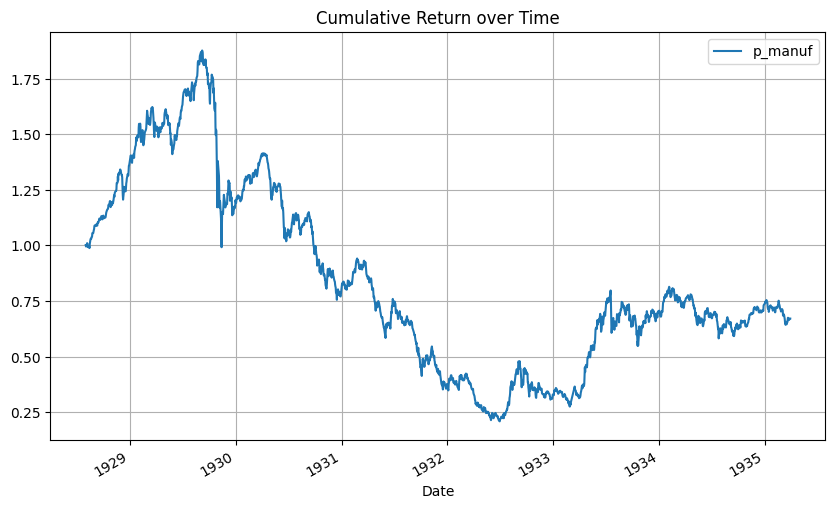

In [50]:
# Plots Date on the X-axis and p_manuf on the Y-axis
filtered_df.plot(x='Date', y='p_manuf', figsize=(10, 6), title='Cumulative Return over Time', grid=True)

# Distribution:

In [51]:
start_date_2006_2016 = '2006-01-01'
end_date_2006_2016 = '2016-12-31'
df_2006_2016 = raw[(raw['Date'] >= start_date_2006_2016) & (raw['Date'] <= end_date_2006_2016)].copy()
asset_list = ['NoDur', 'Durbl', 'Manuf', 'Enrgy', 'HiTec', 'Telcm', 'Shops', 'Hlth', 'Utils', 'Other']

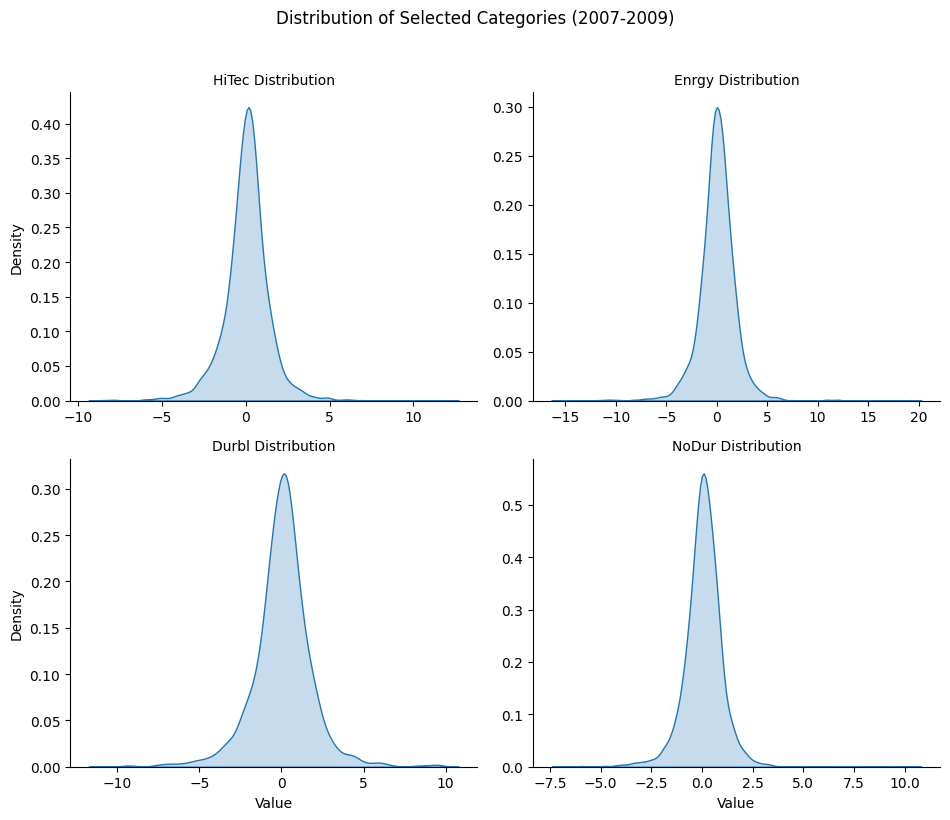

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select the columns of interest
columns_to_plot = ['HiTec', 'Enrgy', 'Durbl', 'NoDur']

# Melt the DataFrame to a long format suitable for FacetGrid
df_melted = df_2006_2016[columns_to_plot].melt(var_name='Category', value_name='Value')

# Create a FacetGrid and map a KDE plot to it
g = sns.FacetGrid(df_melted, col='Category', col_wrap=2, height=4, aspect=1.2, sharex=False, sharey=False)
g.map(sns.kdeplot, 'Value', fill=True)
g.set_axis_labels("Value", "Density")
g.set_titles(template='{col_name} Distribution') # Corrected argument usage: use {col_name}
plt.suptitle('Distribution of Selected Categories (2007-2009)', y=1.02) # Adjust suptitle position
plt.tight_layout()
plt.show()

In [53]:
columns_for_summary = ['HiTec', 'Enrgy', 'Durbl', 'NoDur']

# Calculate summary statistics
summary_stats = df_2006_2016[columns_for_summary].describe()

# Calculate skewness and add it to the summary statistics
skewness = df_2006_2016[columns_for_summary].skew()
summary_stats.loc['skew'] = skewness

# Calculate kurtosis and add it to the summary statistics
kurtosis = df_2006_2016[columns_for_summary].kurt()
summary_stats.loc['kurtosis'] = kurtosis

display(summary_stats)

,HiTec,Enrgy,Durbl,NoDur
count,2769.000000,2769.000000,2769.000000,2769.000000
mean,0.045670,0.038263,0.041120,0.048122
std,1.353926,1.815908,1.816801,0.965429
min,-8.560000,-15.290000,-10.630000,-6.850000
25%,-0.560000,-0.800000,-0.760000,-0.400000
50%,0.100000,0.060000,0.090000,0.080000
75%,0.690000,0.960000,0.920000,0.550000
max,11.880000,19.180000,9.680000,10.240000
skew,0.035164,0.052102,-0.108009,0.052674
kurtosis,6.737382,11.549114,4.796597,10.914089


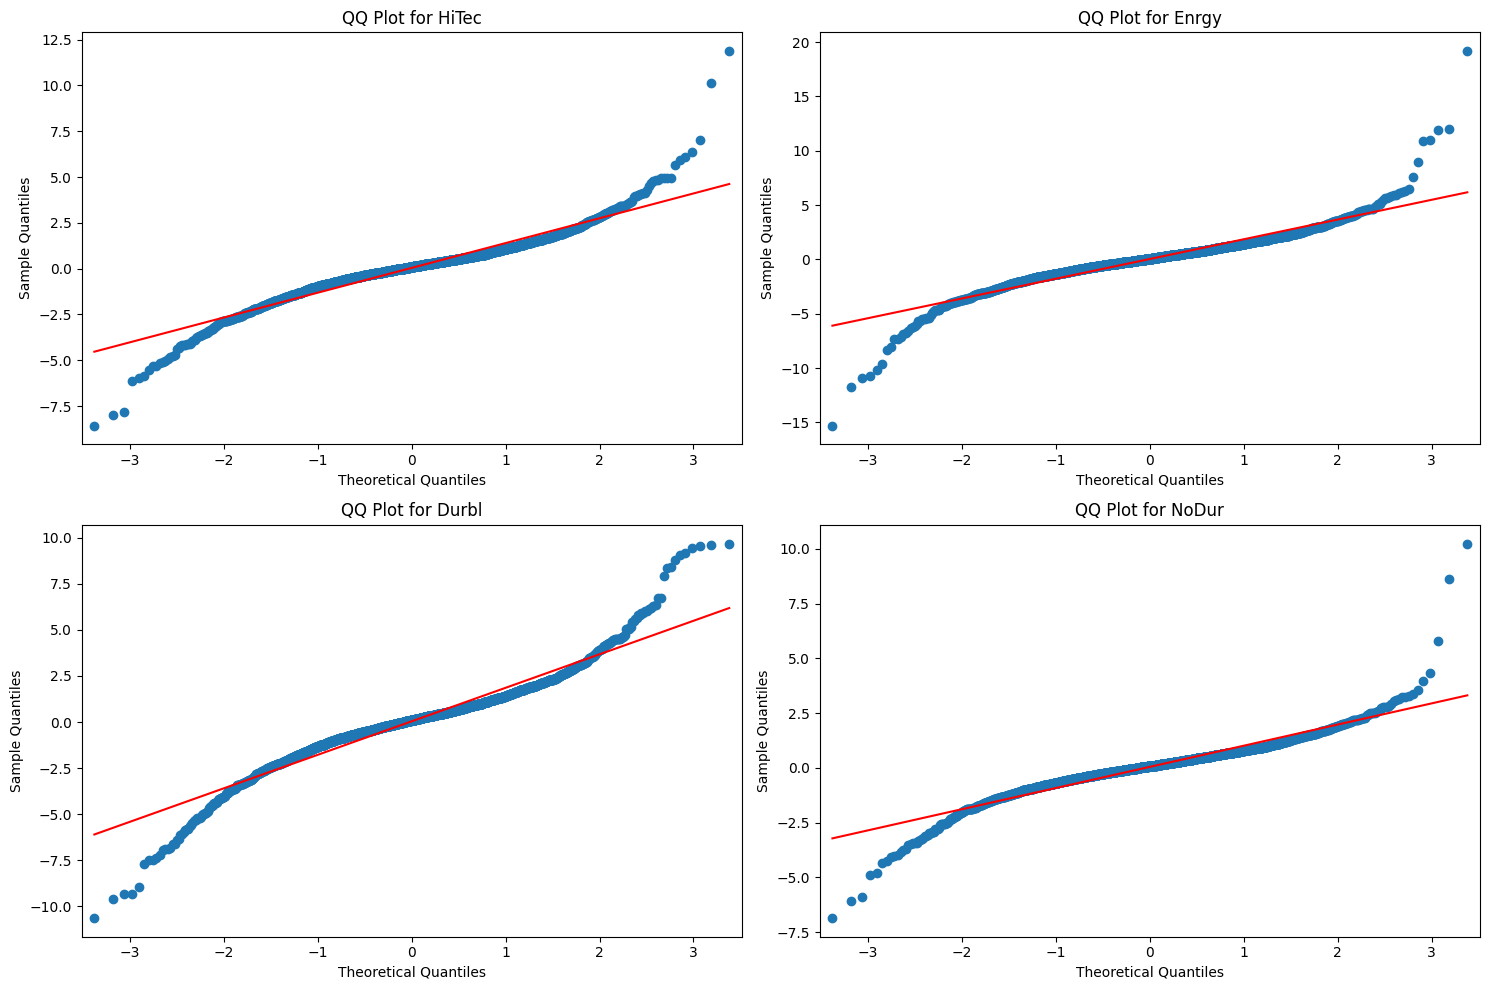

In [54]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

columns_for_qqplot = ['HiTec', 'Enrgy', 'Durbl', 'NoDur']

plt.figure(figsize=(15, 10))
for i, col in enumerate(columns_for_qqplot):
    plt.subplot(2, 2, i + 1) # Create a 2x2 grid of subplots
    sm.qqplot(df_2006_2016[col].dropna(), line='s', ax=plt.gca())
    plt.title(f'QQ Plot for {col}')

plt.tight_layout()
plt.show()

## get distribution type Function

In [55]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from scipy.stats import jarque_bera

def get_distribution_type(returns):
    """
    Analyzes the distribution of a time series, plots the visuals,
    runs statistical tests, and returns the exact string needed for the arch_model.
    """
    # Clean data just in case
    returns = returns.dropna()

    # ---------------------------------------------------------
    # 1. VISUAL CHECKS (Histogram & Q-Q Plot)
    # ---------------------------------------------------------
    fig, ax = plt.subplots(1, 2, figsize=(15, 5))

    # Histogram with Normal Curve Overlay
    sns.histplot(returns, kde=True, stat="density", ax=ax[0], color='teal', bins=50)
    xmin, xmax = ax[0].get_xlim()
    x_line = np.linspace(xmin, xmax, 100)
    p = stats.norm.pdf(x_line, returns.mean(), returns.std())
    ax[0].plot(x_line, p, 'k', linewidth=2, label='Perfect Normal')
    ax[0].set_title('Histogram vs. Normal Distribution')
    ax[0].legend()

    # Q-Q Plot
    sm.qqplot(returns, line='s', ax=ax[1], color='teal')
    ax[1].set_title('Q-Q Plot (Check for Fat Tails)')

    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # 2. STATISTICAL TEST (Jarque-Bera)
    # ---------------------------------------------------------
    jb_stat, jb_p = jarque_bera(returns)
    print("-" * 50)
    print("📊 STATISTICAL TEST (Jarque-Bera)")
    print(f"Test Statistic: {jb_stat:.2f}")
    print(f"P-Value:        {jb_p:.5f}")

    if jb_p < 0.05:
        print("Conclusion:     Data is mathematically NOT Normal (Fat tails exist).")
    else:
        print("Conclusion:     Data appears to be Normal.")

    # ---------------------------------------------------------
    # 3. FIT THE DISTRIBUTIONS (Normal vs. Student's t)
    # ---------------------------------------------------------
    print("\n📐 CALCULATING FIT ERRORS...")

    # Create the actual bins of the data to test against
    y, x_bins = np.histogram(returns, bins=100, density=True)
    x_mid = (x_bins + np.roll(x_bins, -1))[:-1] / 2.0

    # Fit Normal Distribution
    norm_params = stats.norm.fit(returns)
    norm_pdf = stats.norm.pdf(x_mid, *norm_params)
    norm_sse = np.sum((y - norm_pdf)**2)
    print(f"Normal SSE:       {norm_sse:.4f}")

    # Fit Student's t-Distribution
    t_params = stats.t.fit(returns)
    t_pdf = stats.t.pdf(x_mid, *t_params)
    t_sse = np.sum((y - t_pdf)**2)
    print(f"Student's t SSE:  {t_sse:.4f}")

    # ---------------------------------------------------------
    # 4. DETERMINE THE WINNER FOR ARCH LIBRARY
    # ---------------------------------------------------------
    print("-" * 50)
    if t_sse < norm_sse:
        print("🏆 WINNER: Student's t-distribution")
        best_dist = 't'
    else:
        print("🏆 WINNER: Normal distribution")
        best_dist = 'normal'

    print(f"Use this exact parameter in your code: dist='{best_dist}'")
    print("-" * 50)

    return best_dist

# fitting ARCH models:


## find best ARCH model

following function Tests ARCH, GARCH, EGARCH, TARCH, and ARX-GARCH across lags 1 and 2.
Uses the specified distribution type (e.g., 'normal' or 't') for the MLE engine.
Returns the best model name and the fitted results object.

In [56]:
!pip install arch
import itertools
import numpy as np
import pandas as pd
import warnings
from arch import arch_model

# Ignore standard convergence warnings to keep the output clean
warnings.filterwarnings('ignore')

def find_best_volatility_model(returns, dist_type, exog_data=None):
    """
    Tests ARCH, GARCH, EGARCH, TARCH, and ARX-GARCH across lags 1 and 2.
    Returns 6 outputs: name, vol_type, p, q, o, and the fitted results.
    """
    print(f"Starting Grid Search using '{dist_type}' distribution...")

    # 1. Automatic Data Scaling
    if returns.var() < 0.1:
        print("Data variance is tiny. Automatically scaling returns by 100 for optimizer stability...")
        returns = returns * 100

    # 2. Define the grid space
    p_lags = [1, 2]
    o_lags = [0, 1, 2]
    q_lags = [0, 1, 2]
    vol_types = ['Garch', 'EGARCH']

    if exog_data is not None:
        mean_configs = [('Constant', 0), ('ARX', 1), ('ARX', 2)]
        print("Exogenous data detected! Testing Constant and AR-X mean models...")
    else:
        mean_configs = [('Constant', 0)]
        print("No exogenous data. Testing standard Constant mean models...")

    # 3. Trackers for the winner (NOW TRACKING ALL INDIVIDUAL PARAMETERS)
    best_aic = float('inf')
    best_model_name = None
    best_volatility_model = None
    best_p = None
    best_q = None
    best_o = None
    best_results = None

    models_tested = 0
    models_failed = 0

    # 4. The Super-Loop
    for vol in vol_types:
        for p, o, q in itertools.product(p_lags, o_lags, q_lags):

            if vol == 'EGARCH' and q == 0:
                continue

            if vol == 'Garch' and o == 0 and q == 0:
                base_name = f"ARCH({p})"
            elif vol == 'Garch' and o == 0 and q > 0:
                base_name = f"GARCH({p},{q})"
            elif vol == 'Garch' and o > 0:
                base_name = f"TARCH({p},{o},{q})"
            elif vol == 'EGARCH':
                base_name = f"EGARCH({p},{o},{q})"
            else:
                continue

            for mean_type, mean_lags in mean_configs:
                if mean_type == 'ARX':
                    full_name = f"ARX({mean_lags}) - {base_name} [{dist_type}]"
                else:
                    full_name = f"{base_name} [{dist_type}]"

                try:
                    models_tested += 1

                    if mean_type == 'ARX':
                        model = arch_model(returns, x=exog_data, mean=mean_type, lags=mean_lags,
                                           vol=vol, p=p, o=o, q=q, dist=dist_type)
                    else:
                        model = arch_model(returns, mean=mean_type,
                                           vol=vol, p=p, o=o, q=q, dist=dist_type)

                    results = model.fit(disp='off')

                    # ---> THE CHANGE: Save all the individual parameters when we find a winner <---
                    if results.aic < best_aic:
                        best_aic = results.aic
                        best_model_name = full_name
                        best_volatility_model = vol
                        best_p = p
                        best_q = q
                        best_o = o
                        best_results = results

                except Exception:
                    models_failed += 1
                    continue

    # 5. Output the results
    print("-" * 50)
    print(f"Grid Search Complete!")
    print(f"Models successfully tested: {models_tested - models_failed}")
    print(f"Models failed to converge: {models_failed}")
    print(f"\n🏆 CHAMPION MODEL: {best_model_name}")
    print(f"🏆 LOWEST AIC: {best_aic:.2f}")
    print("-" * 50)

    # ---> THE CHANGE: Return exactly the 6 outputs requested <---
    return best_model_name, best_volatility_model, best_p, best_q, best_o, best_results

In [57]:
def creat_best_vol_model_list (df, asset_list):
  results_dist = []
  for asset in asset_list:
      print(f"\n--- Analyzing {asset} ---")

      # 1. Get the distribution type for the current asset
      asset_returns = df_2006_2016[asset].dropna() # Ensure no NaNs for distribution analysis
      my_dist = get_distribution_type(asset_returns)

      # 2. Find the best volatility model for the current asset
      # We only need the best_name for the table
      best_name, best_vol_type, best_p, best_q, best_o, best_model = find_best_volatility_model(asset_returns, my_dist)

      results_dist.append({'Asset Name': asset, 'Best Model': best_name,'Distribution Type' :my_dist , 'Best vol Type' : best_vol_type , 'p' : best_p , 'q':best_q , 'o':best_o})

  # Create a DataFrame from the results
  comparison_table = pd.DataFrame(results_dist)
  return comparison_table




--- Analyzing NoDur ---


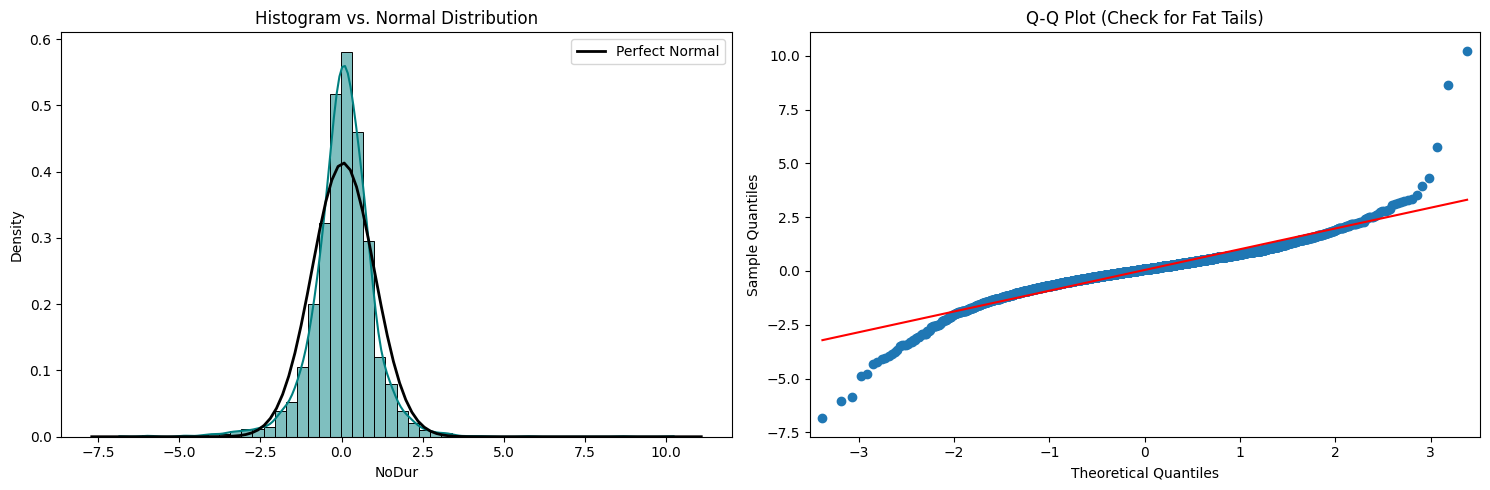

--------------------------------------------------
📊 STATISTICAL TEST (Jarque-Bera)
Test Statistic: 13689.43
P-Value:        0.00000
Conclusion:     Data is mathematically NOT Normal (Fat tails exist).

📐 CALCULATING FIT ERRORS...
Normal SSE:       0.1594
Student's t SSE:  0.0060
--------------------------------------------------
🏆 WINNER: Student's t-distribution
Use this exact parameter in your code: dist='t'
--------------------------------------------------
Starting Grid Search using 't' distribution...
No exogenous data. Testing standard Constant mean models...
--------------------------------------------------
Grid Search Complete!
Models successfully tested: 30
Models failed to converge: 0

🏆 CHAMPION MODEL: EGARCH(1,1,1) [t]
🏆 LOWEST AIC: 6430.24
--------------------------------------------------

--- Analyzing Durbl ---


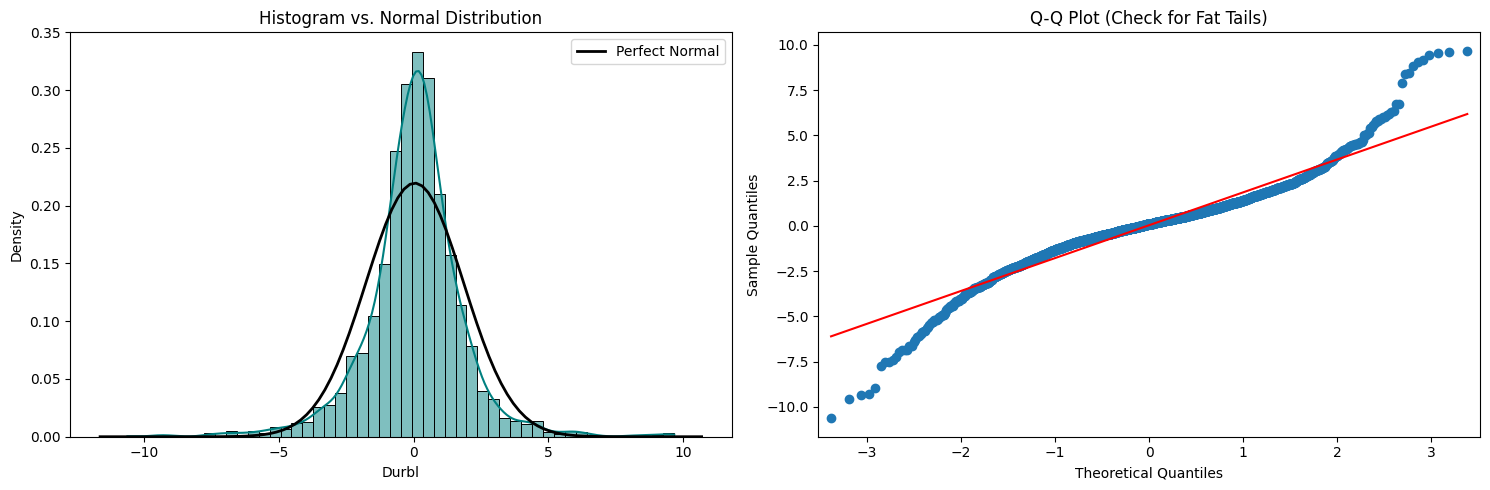

--------------------------------------------------
📊 STATISTICAL TEST (Jarque-Bera)
Test Statistic: 2647.88
P-Value:        0.00000
Conclusion:     Data is mathematically NOT Normal (Fat tails exist).

📐 CALCULATING FIT ERRORS...
Normal SSE:       0.1032
Student's t SSE:  0.0103
--------------------------------------------------
🏆 WINNER: Student's t-distribution
Use this exact parameter in your code: dist='t'
--------------------------------------------------
Starting Grid Search using 't' distribution...
No exogenous data. Testing standard Constant mean models...
--------------------------------------------------
Grid Search Complete!
Models successfully tested: 30
Models failed to converge: 0

🏆 CHAMPION MODEL: EGARCH(2,2,1) [t]
🏆 LOWEST AIC: 9840.73
--------------------------------------------------

--- Analyzing Manuf ---


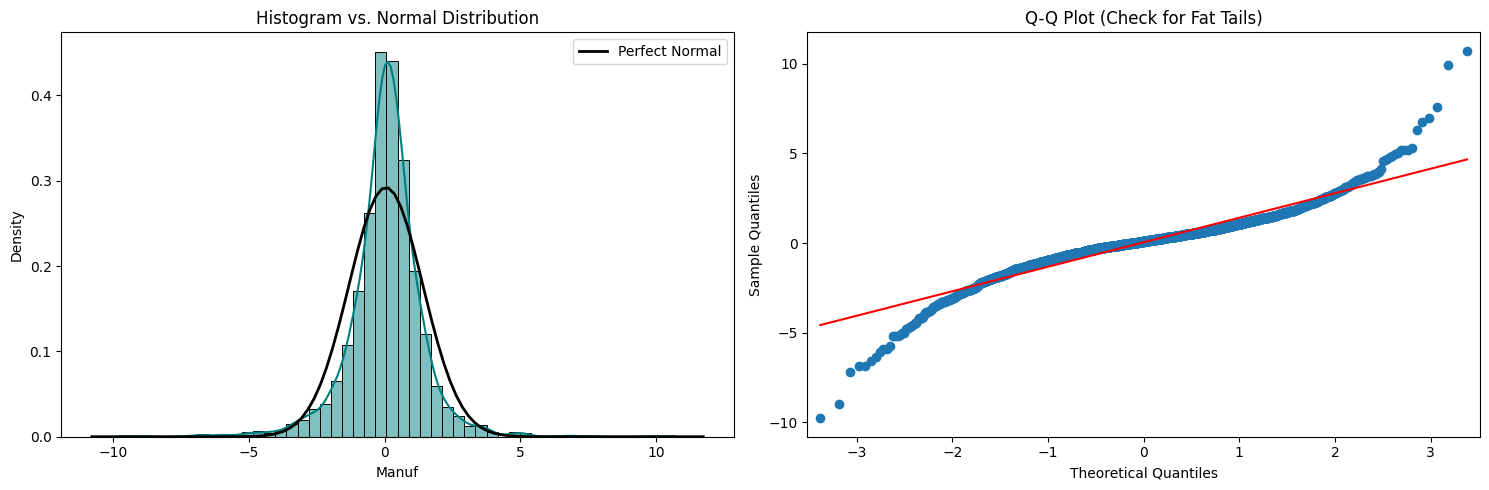

--------------------------------------------------
📊 STATISTICAL TEST (Jarque-Bera)
Test Statistic: 6125.17
P-Value:        0.00000
Conclusion:     Data is mathematically NOT Normal (Fat tails exist).

📐 CALCULATING FIT ERRORS...
Normal SSE:       0.1510
Student's t SSE:  0.0130
--------------------------------------------------
🏆 WINNER: Student's t-distribution
Use this exact parameter in your code: dist='t'
--------------------------------------------------
Starting Grid Search using 't' distribution...
No exogenous data. Testing standard Constant mean models...
--------------------------------------------------
Grid Search Complete!
Models successfully tested: 30
Models failed to converge: 0

🏆 CHAMPION MODEL: EGARCH(2,2,1) [t]
🏆 LOWEST AIC: 8131.41
--------------------------------------------------

--- Analyzing Enrgy ---


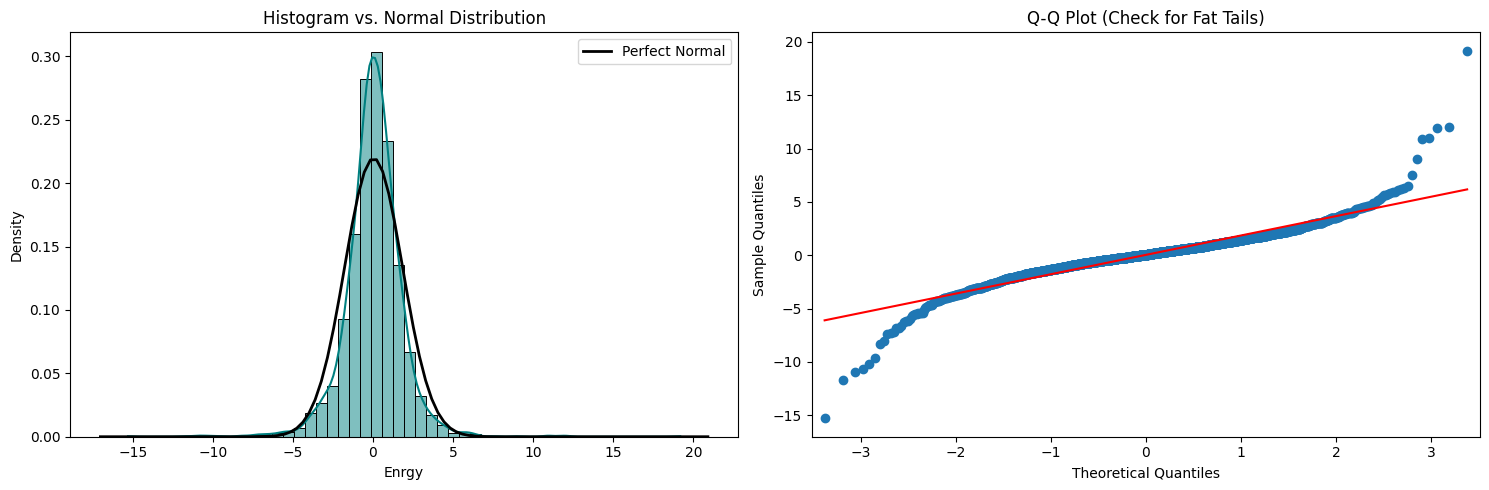

--------------------------------------------------
📊 STATISTICAL TEST (Jarque-Bera)
Test Statistic: 15328.94
P-Value:        0.00000
Conclusion:     Data is mathematically NOT Normal (Fat tails exist).

📐 CALCULATING FIT ERRORS...
Normal SSE:       0.0440
Student's t SSE:  0.0020
--------------------------------------------------
🏆 WINNER: Student's t-distribution
Use this exact parameter in your code: dist='t'
--------------------------------------------------
Starting Grid Search using 't' distribution...
No exogenous data. Testing standard Constant mean models...
--------------------------------------------------
Grid Search Complete!
Models successfully tested: 30
Models failed to converge: 0

🏆 CHAMPION MODEL: EGARCH(2,2,1) [t]
🏆 LOWEST AIC: 9869.00
--------------------------------------------------

--- Analyzing HiTec ---


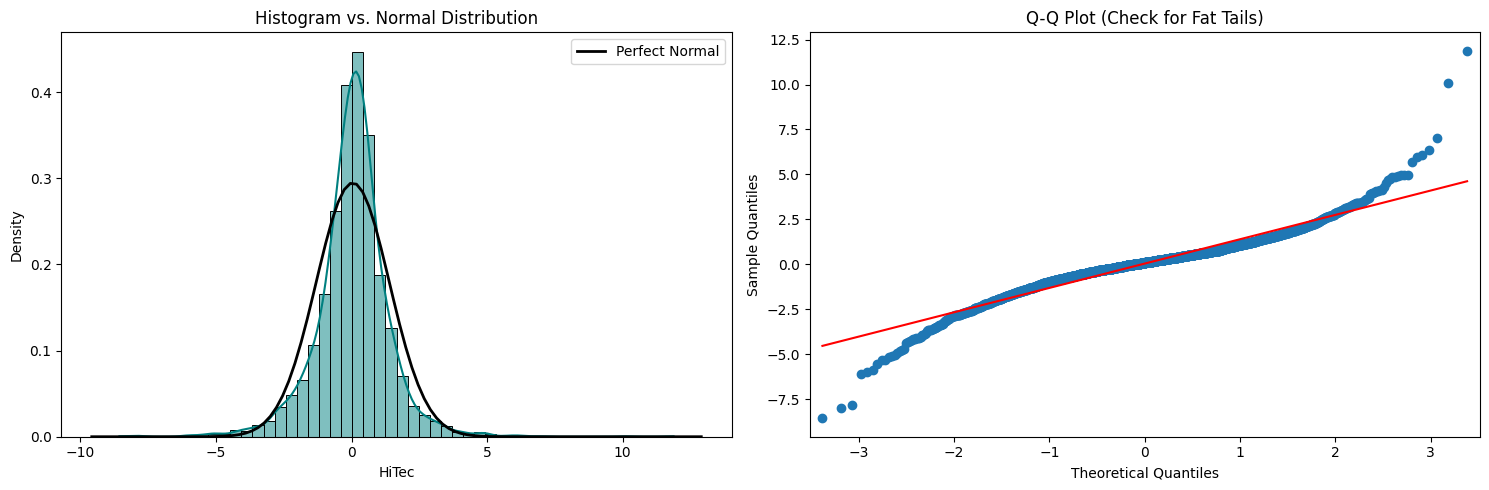

--------------------------------------------------
📊 STATISTICAL TEST (Jarque-Bera)
Test Statistic: 5215.46
P-Value:        0.00000
Conclusion:     Data is mathematically NOT Normal (Fat tails exist).

📐 CALCULATING FIT ERRORS...
Normal SSE:       0.1310
Student's t SSE:  0.0128
--------------------------------------------------
🏆 WINNER: Student's t-distribution
Use this exact parameter in your code: dist='t'
--------------------------------------------------
Starting Grid Search using 't' distribution...
No exogenous data. Testing standard Constant mean models...
--------------------------------------------------
Grid Search Complete!
Models successfully tested: 30
Models failed to converge: 0

🏆 CHAMPION MODEL: EGARCH(2,2,1) [t]
🏆 LOWEST AIC: 8354.90
--------------------------------------------------

--- Analyzing Telcm ---


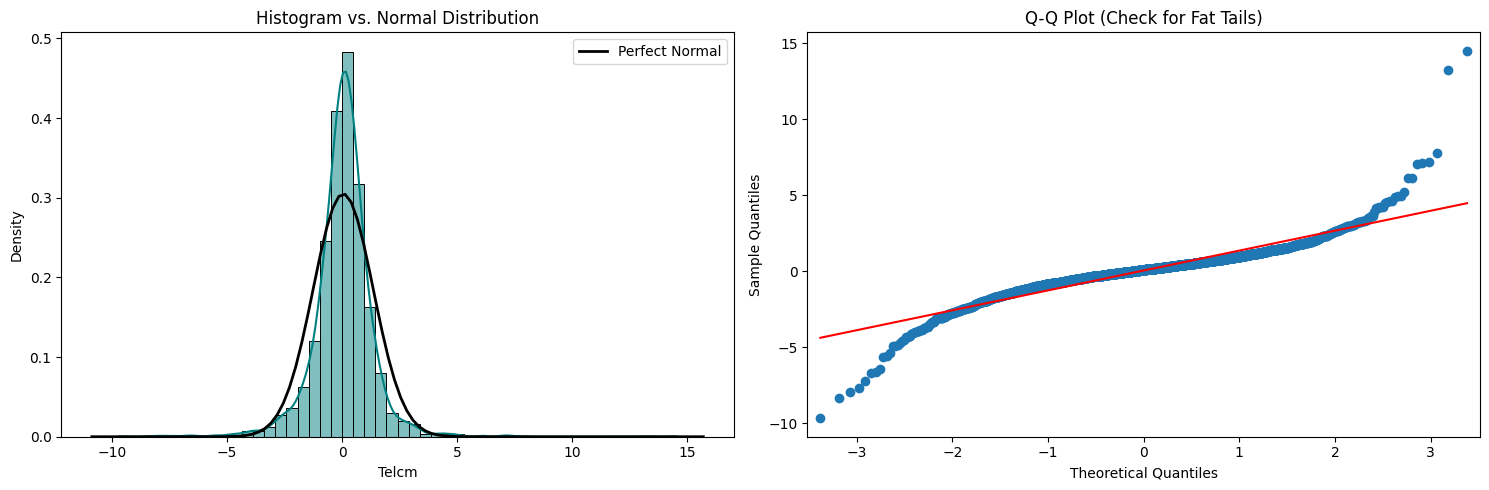

--------------------------------------------------
📊 STATISTICAL TEST (Jarque-Bera)
Test Statistic: 26059.07
P-Value:        0.00000
Conclusion:     Data is mathematically NOT Normal (Fat tails exist).

📐 CALCULATING FIT ERRORS...
Normal SSE:       0.1459
Student's t SSE:  0.0031
--------------------------------------------------
🏆 WINNER: Student's t-distribution
Use this exact parameter in your code: dist='t'
--------------------------------------------------
Starting Grid Search using 't' distribution...
No exogenous data. Testing standard Constant mean models...
--------------------------------------------------
Grid Search Complete!
Models successfully tested: 30
Models failed to converge: 0

🏆 CHAMPION MODEL: TARCH(1,2,2) [t]
🏆 LOWEST AIC: 7696.83
--------------------------------------------------

--- Analyzing Shops ---


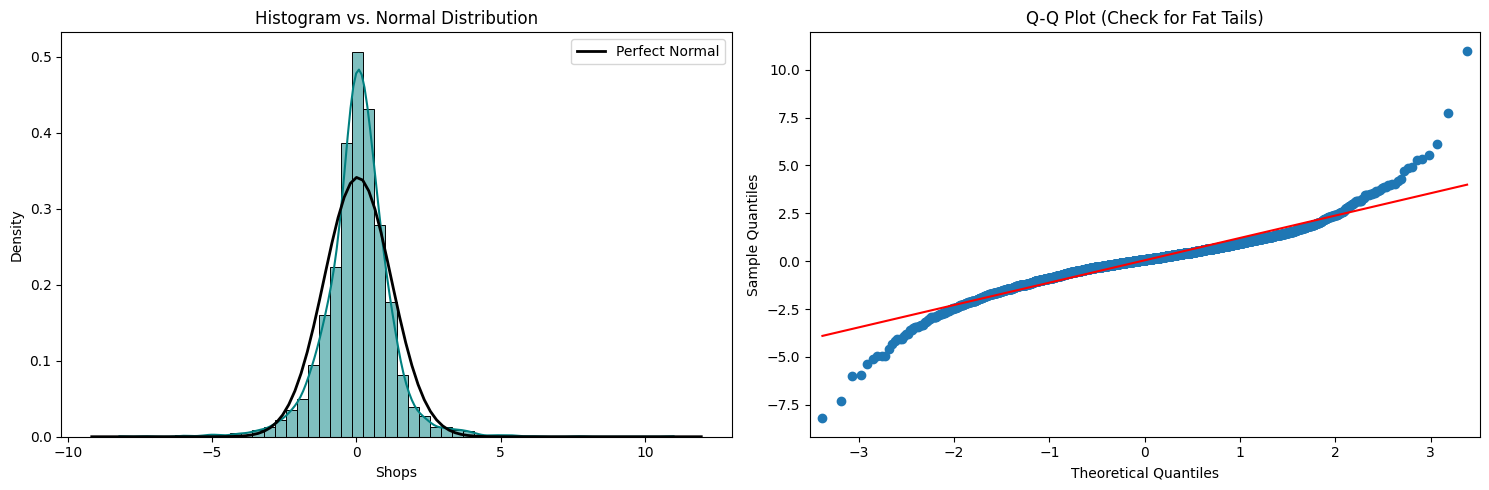

--------------------------------------------------
📊 STATISTICAL TEST (Jarque-Bera)
Test Statistic: 6402.82
P-Value:        0.00000
Conclusion:     Data is mathematically NOT Normal (Fat tails exist).

📐 CALCULATING FIT ERRORS...
Normal SSE:       0.1348
Student's t SSE:  0.0106
--------------------------------------------------
🏆 WINNER: Student's t-distribution
Use this exact parameter in your code: dist='t'
--------------------------------------------------
Starting Grid Search using 't' distribution...
No exogenous data. Testing standard Constant mean models...
--------------------------------------------------
Grid Search Complete!
Models successfully tested: 30
Models failed to converge: 0

🏆 CHAMPION MODEL: EGARCH(2,2,1) [t]
🏆 LOWEST AIC: 7497.82
--------------------------------------------------

--- Analyzing Hlth ---


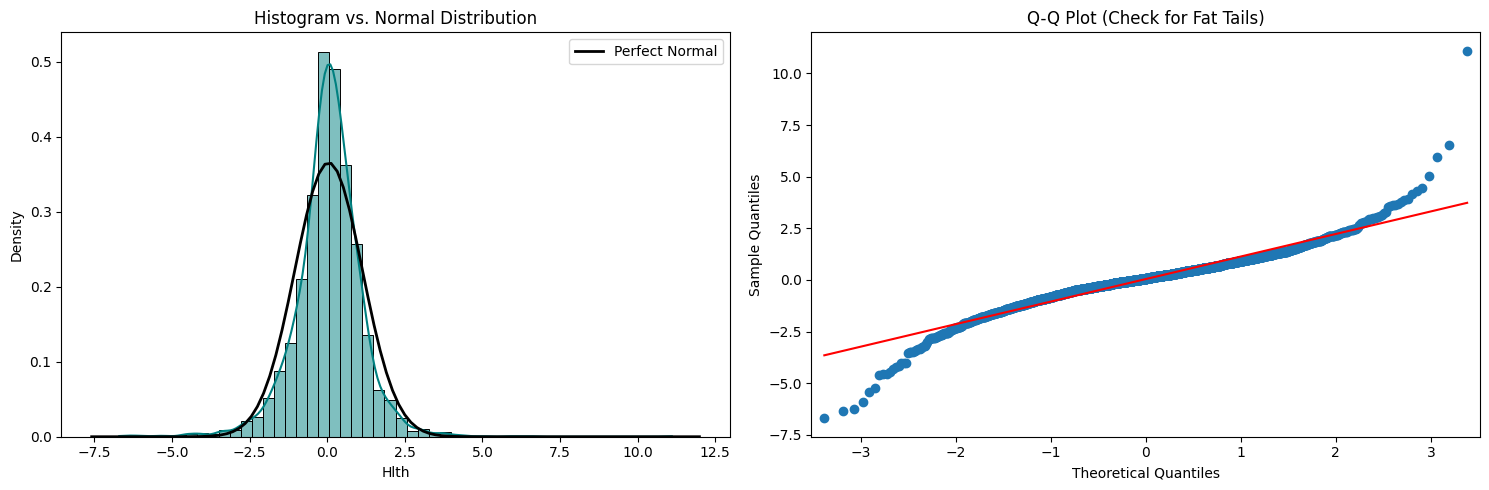

--------------------------------------------------
📊 STATISTICAL TEST (Jarque-Bera)
Test Statistic: 6887.07
P-Value:        0.00000
Conclusion:     Data is mathematically NOT Normal (Fat tails exist).

📐 CALCULATING FIT ERRORS...
Normal SSE:       0.1327
Student's t SSE:  0.0141
--------------------------------------------------
🏆 WINNER: Student's t-distribution
Use this exact parameter in your code: dist='t'
--------------------------------------------------
Starting Grid Search using 't' distribution...
No exogenous data. Testing standard Constant mean models...
--------------------------------------------------
Grid Search Complete!
Models successfully tested: 30
Models failed to converge: 0

🏆 CHAMPION MODEL: EGARCH(2,2,1) [t]
🏆 LOWEST AIC: 7344.71
--------------------------------------------------

--- Analyzing Utils ---


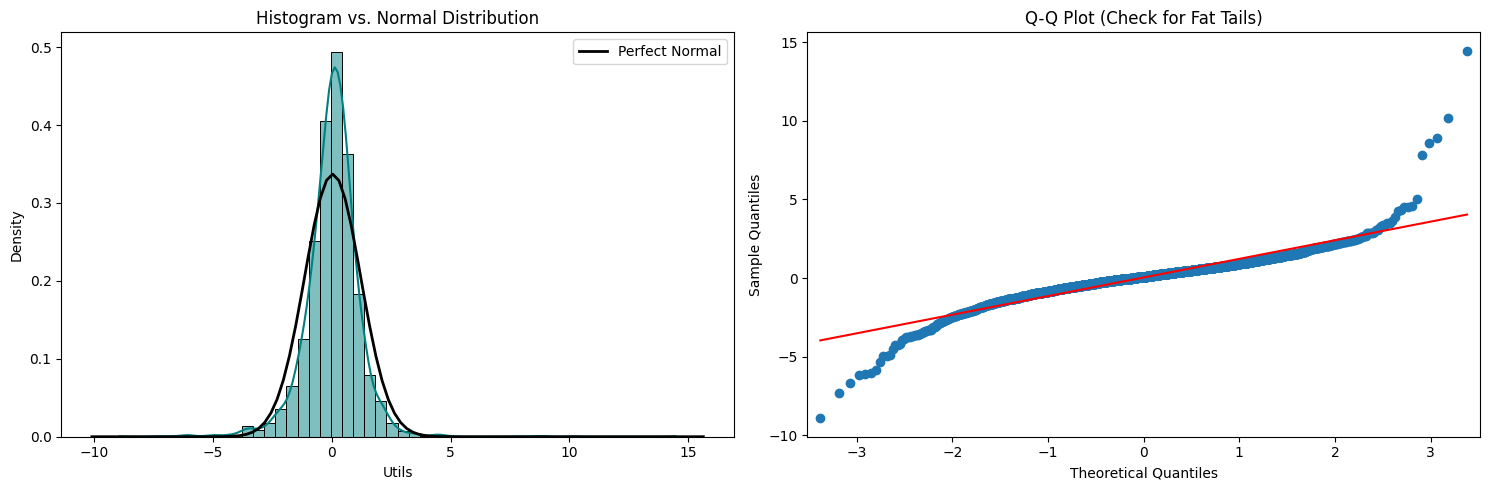

--------------------------------------------------
📊 STATISTICAL TEST (Jarque-Bera)
Test Statistic: 30792.12
P-Value:        0.00000
Conclusion:     Data is mathematically NOT Normal (Fat tails exist).

📐 CALCULATING FIT ERRORS...
Normal SSE:       0.1148
Student's t SSE:  0.0043
--------------------------------------------------
🏆 WINNER: Student's t-distribution
Use this exact parameter in your code: dist='t'
--------------------------------------------------
Starting Grid Search using 't' distribution...
No exogenous data. Testing standard Constant mean models...
--------------------------------------------------
Grid Search Complete!
Models successfully tested: 30
Models failed to converge: 0

🏆 CHAMPION MODEL: TARCH(1,2,2) [t]
🏆 LOWEST AIC: 7448.32
--------------------------------------------------

--- Analyzing Other ---


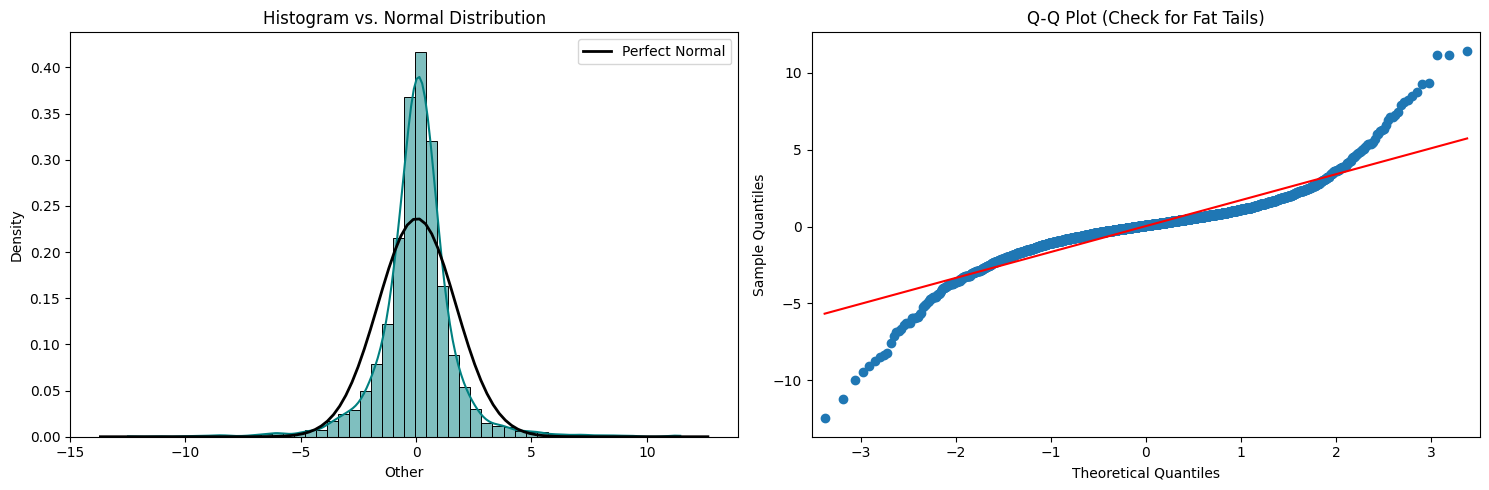

--------------------------------------------------
📊 STATISTICAL TEST (Jarque-Bera)
Test Statistic: 9518.74
P-Value:        0.00000
Conclusion:     Data is mathematically NOT Normal (Fat tails exist).

📐 CALCULATING FIT ERRORS...
Normal SSE:       0.1779
Student's t SSE:  0.0053
--------------------------------------------------
🏆 WINNER: Student's t-distribution
Use this exact parameter in your code: dist='t'
--------------------------------------------------
Starting Grid Search using 't' distribution...
No exogenous data. Testing standard Constant mean models...
--------------------------------------------------
Grid Search Complete!
Models successfully tested: 30
Models failed to converge: 0

🏆 CHAMPION MODEL: TARCH(2,2,1) [t]
🏆 LOWEST AIC: 8732.54
--------------------------------------------------

--- Best Volatility Models per Asset ---


,Asset Name,Best Model,Distribution Type,Best vol Type,p,q,o
0,NoDur,"EGARCH(1,1,1) [t]",t,EGARCH,1,1,1
1,Durbl,"EGARCH(2,2,1) [t]",t,EGARCH,2,1,2
2,Manuf,"EGARCH(2,2,1) [t]",t,EGARCH,2,1,2
3,Enrgy,"EGARCH(2,2,1) [t]",t,EGARCH,2,1,2
4,HiTec,"EGARCH(2,2,1) [t]",t,EGARCH,2,1,2
5,Telcm,"TARCH(1,2,2) [t]",t,Garch,1,2,2
6,Shops,"EGARCH(2,2,1) [t]",t,EGARCH,2,1,2
7,Hlth,"EGARCH(2,2,1) [t]",t,EGARCH,2,1,2
8,Utils,"TARCH(1,2,2) [t]",t,Garch,1,2,2
9,Other,"TARCH(2,2,1) [t]",t,Garch,2,1,2


In [58]:
comparison_table = creat_best_vol_model_list(df_2006_2016, asset_list)

print("\n--- Best Volatility Models per Asset ---")
display(comparison_table)

In [73]:

from arch import arch_model

# 1. Prepare the data (using the 2006-2016 slice defined earlier)
# We scale by 100 as per standard practice to help the optimizer converge
nodur_returns = df_2006_2016['NoDur'].dropna() * 100

# 2. Define the EGARCH(1,1,1) model with a Student's t-distribution
# p=1 (GARCH lag), o=1 (asymmetric lag), q=1 (ARCH lag)
model_nodur = arch_model(
    nodur_returns,
    mean='Constant',
    vol='EGARCH',
    p=1, o=1, q=1,
    dist='t'
)

# 3. Fit the model
res_nodur = model_nodur.fit(disp='off')

# 4. Show the full results
# This includes:
# - Log-Likelihood, AIC, BIC
# - Parameter Estimates and t-tests (P > |t|)
# - Post-estimation diagnostics (Ljung-Box, Heteroskedasticity/ARCH-LM tests)
print(res_nodur.summary())

                        Constant Mean - EGARCH Model Results                        
Dep. Variable:                        NoDur   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                           EGARCH   Log-Likelihood:               -15960.8
Distribution:      Standardized Student's t   AIC:                           31933.7
Method:                  Maximum Likelihood   BIC:                           31969.2
                                              No. Observations:                 2769
Date:                      Fri, Jun 12 2026   Df Residuals:                     2768
Time:                              17:33:31   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu             4

# CAPM model and portfolio optimazation

the following code contain two diffrent CAPM. first is the model does not use the GARCH model and second one use the GARCH model to create a CAPM.
Both models optimazing the portfulio in the end.

## Regular CAPM

Calculates the optimal CAPM portfolio weights maximizing the Sharpe ratio.

In [60]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import scipy.optimize as sco

def optimize_capm_portfolio(df, assets, rf_col='RF', mkt_rf_col='Mkt-RF'):
    """
    Calculates the optimal CAPM portfolio weights maximizing the Sharpe ratio.

    Parameters:
    df (pd.DataFrame): The dataframe containing asset returns, risk-free rate, and market premium.
    assets (list): A list of strings representing the column names of the assets.
    rf_col (str): The column name for the Risk-Free rate.
    mkt_rf_col (str): The column name for the Market Risk Premium.

    Returns:
    dict: A dictionary containing portfolio return, volatility, max sharpe, and optimal weights.
    """
    # Create a copy to avoid altering the original dataframe
    data = df.copy()

    # 1. Calculate excess returns for each asset
    for asset in assets:
        data[f'{asset}_ex'] = data[asset] - data[rf_col]

    # 2. Estimate Betas via OLS
    betas = {}
    X = sm.add_constant(data[mkt_rf_col])
    for asset in assets:
        y = data[f'{asset}_ex']
        model = sm.OLS(y, X).fit()
        betas[asset] = model.params[mkt_rf_col]

    beta_series = pd.Series(betas)

    # 3. Calculate CAPM Expected Returns
    expected_market_premium = data[mkt_rf_col].mean()
    expected_rf = data[rf_col].mean()

    capm_expected_returns = expected_rf + beta_series * expected_market_premium

    # 4. Estimate the Covariance Matrix using the raw asset returns
    cov_matrix = data[assets].cov()

    # 5. Define the objective function (Minimize Negative Sharpe)
    def negative_sharpe(weights, expected_returns, cov_matrix, risk_free_rate):
        port_return = np.dot(weights, expected_returns)
        port_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

        # Prevent division by zero
        if port_volatility == 0:
            return 0

        sharpe_ratio = (port_return - risk_free_rate) / port_volatility
        return -sharpe_ratio

    # 6. Setup constraints and bounds for the optimizer
    num_assets = len(assets)
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1}) # Weights sum to 1
    bounds = tuple((0, 1) for _ in range(num_assets))              # Long-only constraint
    initial_guess = num_assets * [1. / num_assets]                 # Start with equal weights

    # Run the optimization
    optimal_result = sco.minimize(
        negative_sharpe,
        initial_guess,
        args=(capm_expected_returns.values, cov_matrix.values, expected_rf),
        method='SLSQP',
        bounds=bounds,
        constraints=constraints
    )

    # 7. Extract Outputs
    optimal_weights_array = optimal_result.x
    portfolio_return = np.dot(optimal_weights_array, capm_expected_returns)
    portfolio_volatility = np.sqrt(np.dot(optimal_weights_array.T, np.dot(cov_matrix, optimal_weights_array)))
    max_sharpe = (portfolio_return - expected_rf) / portfolio_volatility

    # Clean up the weights into a readable dictionary (rounding to 4 decimal places)
    optimal_weights_dict = {
        asset: round(weight, 4)
        for asset, weight in zip(assets, optimal_weights_array)
    }

    return {
        'portfolio_return': portfolio_return,
        'portfolio_volatility': portfolio_volatility,
        'max_sharpe': max_sharpe,
        'optimal_weights': optimal_weights_dict
    }

In [61]:

# Define your asset list
asset_list = ['NoDur', 'Durbl', 'Manuf', 'Enrgy', 'HiTec', 'Telcm', 'Shops', 'Hlth', 'Utils', 'Other']

# Run the function on dataframe
result_capm = optimize_capm_portfolio(df=df_2006_2016, assets=asset_list, rf_col='RF', mkt_rf_col='Mkt-RF')


# Print the neatly formatted results
print(f"Return:    {result_capm['portfolio_return']:.6f}")
print(f"Volatility:{result_capm['portfolio_volatility']:.6f}")
print(f"Sharpe:    {result_capm['max_sharpe']:.6f}")
print("\nOptimal Weights:")
for asset, weight in result_capm['optimal_weights'].items():
    if weight > 0.001:  # Only show assets that actually get an allocation
        print(f"{asset}: {weight*100:.2f}%")

Return:    0.038603
Volatility:1.262288
Sharpe:    0.027292

Optimal Weights:
NoDur: 8.70%
Durbl: 8.41%
Manuf: 10.21%
Enrgy: 5.72%
HiTec: 13.57%
Telcm: 8.88%
Shops: 11.00%
Hlth: 11.09%
Utils: 4.49%
Other: 17.93%


## CAPM with GARCH

Calculates the optimal CAPM portfolio using 1-step-ahead GARCH volatility forecasts.

In [62]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import scipy.optimize as sco
from arch import arch_model
import warnings

# Suppress arch convergence warnings for cleaner output
warnings.filterwarnings('ignore')

def optimize_garch_capm_portfolio(df, assets, rf_col='RF', mkt_rf_col='Mkt-RF', vol_model='GARCH', p=1, o=0, q=1):
    """
    Calculates the optimal CAPM portfolio using 1-step-ahead GARCH volatility forecasts.

    Parameters:
    df (pd.DataFrame): The dataframe containing asset returns, risk-free rate, and market premium.
    assets (list): A list of strings representing the column names of the assets.
    rf_col (str): The column name for the Risk-Free rate.
    mkt_rf_col (str): The column name for the Market Risk Premium.
    vol_model (str): The type of GARCH model (e.g., 'GARCH', 'EGARCH').
    p, o, q (int): The lag orders for the GARCH model.

    Returns:
    dict: A dictionary containing forecasted return, volatility, max sharpe, and dynamic optimal weights.
    """
    data = df.copy()

    # Scale data by 100 to help GARCH optimization convergence (standard practice for daily returns)
    scale_factor = 100.0
    for col in assets + [rf_col, mkt_rf_col]:
        data[col] = data[col] * scale_factor

    # 1. Calculate excess returns
    for asset in assets:
        data[f'{asset}_ex'] = data[asset] - data[rf_col]

    # 2. Forecast 1-step-ahead Volatility using GARCH
    forecasted_vol = {}

    # Fit GARCH for the Market Proxy
    am_mkt = arch_model(data[mkt_rf_col], vol=vol_model, p=p, o=o, q=q, rescale=False)
    res_mkt = am_mkt.fit(disp='off')
    # Extract tomorrow's forecasted standard deviation
    forecasted_vol['Market'] = np.sqrt(res_mkt.forecast(horizon=1).variance.iloc[-1, 0])

    # Fit GARCH for each Asset
    for asset in assets:
        am = arch_model(data[f'{asset}_ex'], vol=vol_model, p=p, o=o, q=q, rescale=False)
        res = am.fit(disp='off')
        forecasted_vol[asset] = np.sqrt(res.forecast(horizon=1).variance.iloc[-1, 0])

    # 3. Construct the Conditional Covariance Matrix (CCC-GARCH approach)
    cols_for_corr = [f'{a}_ex' for a in assets] + [mkt_rf_col]
    hist_corr = data[cols_for_corr].corr() # Historical correlation matrix

    num_assets = len(assets)
    forecasted_cov_matrix = np.zeros((num_assets, num_assets))

    for i, a1 in enumerate(assets):
        for j, a2 in enumerate(assets):
            rho = hist_corr.loc[f'{a1}_ex', f'{a2}_ex']
            # Conditional Covariance = Correlation * Forecasted Vol 1 * Forecasted Vol 2
            forecasted_cov_matrix[i, j] = rho * forecasted_vol[a1] * forecasted_vol[a2]

    # 4. Calculate Dynamic Betas and Forecasted Expected Returns
    expected_market_premium = data[mkt_rf_col].mean()
    expected_rf = data[rf_col].iloc[-1] # Use the most recent risk-free rate

    dynamic_betas = {}
    capm_expected_returns = []

    for asset in assets:
        # Extract correlation between asset and market
        rho_im = hist_corr.loc[f'{asset}_ex', mkt_rf_col]

        # Forecasted Covariance between Asset and Market
        cov_im = rho_im * forecasted_vol[asset] * forecasted_vol['Market']

        # Dynamic Beta = Cov(i, m) / Var(m)
        beta_i = cov_im / (forecasted_vol['Market'] ** 2)
        dynamic_betas[asset] = beta_i

        # Conditional CAPM Expected Return for tomorrow
        e_ri = expected_rf + beta_i * expected_market_premium
        capm_expected_returns.append(e_ri)

    capm_expected_returns = np.array(capm_expected_returns)

    # 5. Optimize the Portfolio (Maximize forecasted Sharpe Ratio)
    def negative_sharpe(weights, expected_returns, cov_matrix, risk_free_rate):
        port_return = np.dot(weights, expected_returns)
        port_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
        if port_volatility == 0:
            return 0
        sharpe_ratio = (port_return - risk_free_rate) / port_volatility
        return -sharpe_ratio

    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0, 1) for _ in range(num_assets))
    initial_guess = num_assets * [1. / num_assets]

    optimal_result = sco.minimize(
        negative_sharpe,
        initial_guess,
        args=(capm_expected_returns, forecasted_cov_matrix, expected_rf),
        method='SLSQP',
        bounds=bounds,
        constraints=constraints
    )

    # 6. Extract and rescale outputs back to original format
    optimal_weights_array = optimal_result.x
    port_return_scaled = np.dot(optimal_weights_array, capm_expected_returns)
    port_volatility_scaled = np.sqrt(np.dot(optimal_weights_array.T, np.dot(forecasted_cov_matrix, optimal_weights_array)))

    max_sharpe = (port_return_scaled - expected_rf) / port_volatility_scaled

    optimal_weights_dict = {asset: round(weight, 4) for asset, weight in zip(assets, optimal_weights_array)}

    return {
        'forecasted_portfolio_return': port_return_scaled / scale_factor,
        'forecasted_portfolio_volatility': port_volatility_scaled / scale_factor,
        'max_sharpe': max_sharpe, # Sharpe ratio is unitless, doesn't need rescaling
        'dynamic_betas': {k: round(v, 4) for k, v in dynamic_betas.items()},
        'optimal_weights': optimal_weights_dict
    }

In [63]:
result_capm_garch = optimize_garch_capm_portfolio(df=df_2006_2016, assets=asset_list, rf_col='RF', mkt_rf_col='Mkt-RF', vol_model='EGARCH', p=2, o=2, q=1)

/tmp/ipykernel_4413/1279540356.py:49: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  res = am.fit(disp='off')


# Copula setup:

based on the Sklar's Theorem a joint distribution can be completely separated into two distinct parts:

1.The individual behavior of each asset (the marginal distributions).

2.The relationship between them (the copula).

to calculate the marginal distribution of each asset useing the best GARCH model for each assets and canculate the residuals for the copula part.

## create residuals:


In [64]:
from arch import arch_model

# Iterate through each asset in the comparison table
for index, row in comparison_table.iterrows():
    asset = row['Asset Name']
    vol_type = row['Best vol Type']
    p = int(row['p'])
    q = int(row['q'])
    o = int(row['o'])
    dist = row['Distribution Type']

    print(f"Fitting {row['Best Model']} for {asset}...")

    # Prepare the returns data
    returns = df_2006_2016[asset]

    # Handle scaling if variance is low
    scale_factor = 1.0
    if returns.var() < 0.1:
        scale_factor = 100.0

    scaled_returns = returns * scale_factor

    # Initialize and fit the specific model
    model = arch_model(
        scaled_returns,
        vol=vol_type,
        p=p,
        o=o,
        q=q,
        dist=dist,
        mean='Constant'
    )

    res = model.fit(disp='off')

    # Calculate standardized residuals: (epsilon_t / sigma_t)
    df_2006_2016[f'{asset}_resid'] = res.resid / res.conditional_volatility

print("\nStandardized residuals successfully calculated and added to df_2006_2016.")
display(df_2006_2016[[col for col in df_2006_2016.columns if '_resid' in col]].head())

Fitting EGARCH(1,1,1) [t] for NoDur...
Fitting EGARCH(2,2,1) [t] for Durbl...
Fitting EGARCH(2,2,1) [t] for Manuf...
Fitting EGARCH(2,2,1) [t] for Enrgy...
Fitting EGARCH(2,2,1) [t] for HiTec...
Fitting TARCH(1,2,2) [t] for Telcm...
Fitting EGARCH(2,2,1) [t] for Shops...
Fitting EGARCH(2,2,1) [t] for Hlth...
Fitting TARCH(1,2,2) [t] for Utils...
Fitting TARCH(2,2,1) [t] for Other...

Standardized residuals successfully calculated and added to df_2006_2016.


,NoDur_resid,Durbl_resid,Manuf_resid,Enrgy_resid,HiTec_resid,Telcm_resid,Shops_resid,Hlth_resid,Utils_resid,Other_resid
21120,1.266090,0.621943,1.802937,2.622800,1.781450,1.386957,0.731327,1.772449,2.513659,1.821670
21121,0.803418,1.006385,0.871066,0.214454,1.261241,0.617329,-0.286916,1.569901,-0.018107,0.126832
21122,-0.614008,1.049067,-0.367693,-0.720017,0.986453,0.553690,-0.812961,-0.033662,-0.916240,0.123749
21123,1.441083,1.010088,1.392226,1.209651,1.833216,2.041554,0.892152,0.788363,1.037419,0.725860
21124,0.756982,1.120739,0.774470,-0.037320,0.462162,0.390467,1.208485,1.618863,-0.254629,0.610276


## creating uniform distributions

### Semiparametric Approach

$$U_{t} = \frac{1}{T+1} \sum_{j=1}^T \mathbf{1}_{\{ \hat{\varepsilon}_{j} \le \hat{\varepsilon}_{t} \}}$$

In [65]:
from scipy.stats import rankdata

def calculate_u_empirical(df, asset_name, residual_col):
    """
    Calculates empirical uniform probabilities (U_t) from residuals.
    Formula: U_t = Rank(resid_t) / (T + 1)
    """
    residuals = df[residual_col].values
    T = len(residuals)

    # rankdata assigns rank 1 to the smallest value, T to the largest
    ranks = rankdata(residuals)

    # Convert ranks to uniform probabilities [0, 1]
    # Renamed to u_emp_{asset_name} for clarity vs uparam_{asset_name}
    u_col_name = f'u_emp_{asset_name}'
    df[u_col_name] = ranks / (T + 1)

    return df

# Example usage for all assets in your list:
for asset in asset_list:
    resid_col = f'{asset}_resid'
    if resid_col in df_2006_2016.columns:
        df_2006_2016 = calculate_u_empirical(df_2006_2016, asset, resid_col)

print("Empirical uniform distributions (u_emp_asset) added to df_2006_2016.")
display(df_2006_2016[[col for col in df_2006_2016.columns if 'u_emp_' in col]].head())

Empirical uniform distributions (u_emp_asset) added to df_2006_2016.


,u_emp_NoDur,u_emp_Durbl,u_emp_Manuf,u_emp_Enrgy,u_emp_HiTec,u_emp_Telcm,u_emp_Shops,u_emp_Hlth,u_emp_Utils,u_emp_Other
21120,0.912274,0.751264,0.977617,0.996390,0.976534,0.931047,0.783394,0.971841,0.997473,0.969675
21121,0.801444,0.854874,0.830686,0.584477,0.914440,0.740433,0.359928,0.951264,0.476895,0.551986
21122,0.248736,0.865343,0.321661,0.220217,0.861011,0.718051,0.192058,0.471841,0.168592,0.549097
21123,0.941155,0.855235,0.937545,0.896029,0.977978,0.985560,0.828520,0.802527,0.869675,0.789892
21124,0.787726,0.880866,0.803971,0.479422,0.697112,0.654874,0.903249,0.956679,0.368231,0.754874


### Parametric Approach:

$$U_t = F_{\text{parametric}}(\hat{\varepsilon}_t ; \theta)$$

In [66]:
import numpy as np
from scipy.stats import t

def calculate_u_parametric(df, asset_name, residual_col):
    """
    Calculates parametric uniform probabilities (U_t) from residuals using a t-distribution.
    Formula: U_t = F_t(resid_t ; theta)
    """
    residuals = df[residual_col].dropna().values

    # 1. Fit the t-distribution to your data to find the parameters
    # Returns degrees of freedom (df_fit), location (loc), and scale (scale)
    df_fit, loc, scale = t.fit(residuals)

    # 2. Pass the data through the fitted Cumulative Distribution Function (CDF)
    u_col_name = f'uparam_{asset_name}'
    df[u_col_name] = t.cdf(df[residual_col], df_fit, loc, scale)

    return df

# Example usage for all assets in your list:
for asset in asset_list:
    resid_col = f'{asset}_resid'
    if resid_col in df_2006_2016.columns:
        df_2006_2016 = calculate_u_parametric(df_2006_2016, asset, resid_col)

print("Parametric uniform distributions (uparam_asset) added to df_2006_2016.")
display(df_2006_2016[[col for col in df_2006_2016.columns if 'uparam_' in col]].head())

Parametric uniform distributions (uparam_asset) added to df_2006_2016.


,uparam_NoDur,uparam_Durbl,uparam_Manuf,uparam_Enrgy,uparam_HiTec,uparam_Telcm,uparam_Shops,uparam_Hlth,uparam_Utils,uparam_Other
21120,0.903558,0.748974,0.963971,0.993017,0.962578,0.923348,0.781647,0.961679,0.990676,0.966049
21121,0.800001,0.857158,0.824787,0.588983,0.907295,0.745564,0.375355,0.944659,0.490078,0.558307
21122,0.248904,0.866518,0.340365,0.222394,0.854843,0.723487,0.191104,0.482369,0.163938,0.556929
21123,0.928755,0.857991,0.925133,0.893892,0.965881,0.976910,0.827200,0.799945,0.862234,0.790169
21124,0.786286,0.881114,0.797888,0.482498,0.693853,0.662245,0.895598,0.949322,0.389002,0.752873


# Copula models:

##  1. Normal Copula
Summary: The Normal (Gaussian) copula assumes symmetric, linear dependence between variables. It has zero tail dependence, meaning it assumes extreme events (market crashes or massive booms) are independent.Equation:$$C(u,v;\rho) = \Phi_\rho(\Phi^{-1}(u), \Phi^{-1}(v))$$where $\Phi_\rho$ is the bivariate normal CDF with correlation $\rho$, and $\Phi^{-1}$ is the inverse standard normal CDF.

In [67]:
!pip install copulae
from copulae import NormalCopula
import numpy as np

# Selecting the empirical uniform transformed data
u = df_2006_2016['u_emp_Durbl']
v = df_2006_2016['u_emp_HiTec']

# Prepare the bivariate data matrix
data = np.column_stack((u, v))

# Initialize and fit the Normal (Gaussian) Copula
norm_cop = NormalCopula(dim=2)
norm_cop.fit(data)

print("Normal Copula Parameter (Rho):")
print(norm_cop.params)
print("\nSummary of fitted Copula:")
print(norm_cop.summary())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 4.4 MB/s eta 0:00:00
  Attempting uninstall: wrapt
    Found existing installation: wrapt 2.2.1
    Uninstalling wrapt-2.2.1:
      Successfully uninstalled wrapt-2.2.1
Normal Copula Parameter (Rho):
[0.79407402]

Summary of fitted Copula:
Gaussian Copula Summary
Gaussian Copula with 2 dimensions


Parameters
--------------------------------------------------------------------------------
 Correlation Matrix 
1.000000 0.794074
0.794074 1.000000



## 2. Student's t-Copula
Summary: Unlike the Normal copula, the Student's t-copula captures **tail dependence**. This means it accounts for the tendency of markets to crash (or boom) together more frequently than a normal distribution would predict.

Equation:
$$C(u,v; \rho, \nu) = t_{\rho, \nu}(t_\nu^{-1}(u), t_\nu^{-1}(v))$$
where $\nu$ represents the degrees of freedom (lower $\nu$ = heavier tails/stronger joint extremes).

In [68]:
from copulae import StudentCopula

# Using the same bivariate data (Durbl & HiTec)
# Initialize and fit the Student's t-Copula
t_cop = StudentCopula(dim=2)
t_cop.fit(data)

print("Student's t-Copula Parameters:")
print(f"Correlation (Rho): {t_cop.params.rho[0]:.4f}")
print(f"Degrees of Freedom (Nu): {t_cop.params.df:.4f}")

print("\nSummary of fitted t-Copula:")
print(t_cop.summary())

Student's t-Copula Parameters:
Correlation (Rho): 0.8059
Degrees of Freedom (Nu): 5.3820

Summary of fitted t-Copula:
Student Copula Summary
Student Copula with 2 dimensions


Parameters
--------------------------------------------------------------------------------
 Degree of Freedom  : 5.381979119782145

 Correlation Matrix 
1.000000 0.805944
0.805944 1.000000



## 3. Clayton Copula
Summary: The Clayton copula is asymmetric and sensitive to **lower-tail dependence**. It is widely used in finance because it models the behavior where assets correlate more strongly during market downturns than during upturns.

Equation:
$$C(u,v; \theta) = (u^{-\theta} + v^{-\theta} - 1)^{-1/\theta}$$
where $\theta > 0$ represents the dependence strength.

In [69]:
from copulae import ClaytonCopula

# Initialize and fit the Clayton Copula
clayton_cop = ClaytonCopula(dim=2)
clayton_cop.fit(data)

print("Clayton Copula Parameter (Theta):")
print(f"{clayton_cop.params:.4f}")

print("\nSummary of fitted Clayton Copula:")
print(clayton_cop.summary())

Clayton Copula Parameter (Theta):
2.0905

Summary of fitted Clayton Copula:
Clayton Copula Summary
Clayton Copula with 2 dimensions


Parameters
--------------------------------------------------------------------------------
       theta        : 2.090516312077703



## 4. Gumbel Copula
Summary: The Gumbel copula is asymmetric and sensitive to **upper-tail dependence**. It models the behavior where assets correlate more strongly during large positive gains.

Equation:
$$C(u,v; \theta) = \exp\left(-\left[(-\ln u)^\theta + (-\ln v)^\theta\right]^{1/\theta}\right)$$
where $\theta \ge 1$.

In [70]:
from copulae import GumbelCopula

# Initialize and fit the Gumbel Copula
gumbel_cop = GumbelCopula(dim=2)
gumbel_cop.fit(data)

print("Gumbel Copula Parameter (Theta):")
print(f"{gumbel_cop.params:.4f}")

print("\nSummary of fitted Gumbel Copula:")
print(gumbel_cop.summary())

Gumbel Copula Parameter (Theta):
2.2810

Summary of fitted Gumbel Copula:
Gumbel Copula Summary
Gumbel Copula with 2 dimensions


Parameters
--------------------------------------------------------------------------------
       theta        : 2.280983016694452



## 5. Model Comparison and Selection
We compare the goodness-of-fit using information criteria (AIC/BIC). The model with the **highest Log-Likelihood** and **lowest AIC/BIC** is statistically the best fit for the joint dependence between these two assets.

In [74]:
import pandas as pd
import numpy as np

# Create a list to store the fit metrics
model_comparison = []
n_obs = len(data)

# Define models and their respective number of parameters
# Normal: rho (1), Student-t: rho & df (2), Clayton: theta (1), Gumbel: theta (1)
copula_info = {
    'Normal': {'model': norm_cop, 'params': 1},
    'Student-t': {'model': t_cop, 'params': 2},
    'Clayton': {'model': clayton_cop, 'params': 1},
    'Gumbel': {'model': gumbel_cop, 'params': 1}
}

for name, info in copula_info.items():
    cop = info['model']
    k = info['params']
    ll = cop.log_lik(data)

    # Calculate AIC and BIC manually:
    # AIC = -2*LL + 2*k
    # BIC = -2*LL + ln(n)*k
    aic = -2 * ll + 2 * k
    bic = -2 * ll + np.log(n_obs) * k

    model_comparison.append({
        'Copula Model': name,
        'Log-Likelihood': ll,
        'AIC': aic,
        'BIC': bic
    })

# Display the results sorted by AIC
comparison_df = pd.DataFrame(model_comparison).sort_values(by='AIC')
print("--- Copula Goodness-of-Fit Comparison ---")
display(comparison_df)

--- Copula Goodness-of-Fit Comparison ---


,Copula Model,Log-Likelihood,AIC,BIC
1,Student-t,1468.777130,-2933.554260,-2921.701777
0,Normal,1373.249720,-2744.499441,-2738.573199
3,Gumbel,1284.831512,-2567.663023,-2561.736782
2,Clayton,1239.398961,-2476.797922,-2470.871681


## 5. Model Comparison and Selection
We compare the goodness-of-fit using information criteria (AIC/BIC). The model with the **highest Log-Likelihood** and **lowest AIC/BIC** is statistically the best fit for the joint dependence between these two assets.

In [75]:
import pandas as pd
import numpy as np

# Function to calculate AIC and BIC manually
def calc_information_criteria(log_lik, n_params, n_obs):
    aic = -2 * log_lik + 2 * n_params
    bic = -2 * log_lik + np.log(n_obs) * n_params
    return aic, bic

model_comparison = []
n_obs = len(data)

# Define models and their respective number of parameters
# Normal: rho (1), Student-t: rho, df (2), Clayton: theta (1), Gumbel: theta (1)
copula_info = {
    'Normal': {'model': norm_cop, 'params': 1},
    'Student-t': {'model': t_cop, 'params': 2},
    'Clayton': {'model': clayton_cop, 'params': 1},
    'Gumbel': {'model': gumbel_cop, 'params': 1}
}

for name, info in copula_info.items():
    cop = info['model']
    k = info['params']
    ll = cop.log_lik(data)
    aic, bic = calc_information_criteria(ll, k, n_obs)

    model_comparison.append({
        'Copula Model': name,
        'Log-Likelihood': ll,
        'AIC': aic,
        'BIC': bic
    })

# Display the results sorted by AIC (lower is better)
comparison_df = pd.DataFrame(model_comparison).sort_values(by='AIC')
print("--- Copula Goodness-of-Fit Comparison ---")
display(comparison_df)

--- Copula Goodness-of-Fit Comparison ---


,Copula Model,Log-Likelihood,AIC,BIC
1,Student-t,1468.777130,-2933.554260,-2921.701777
0,Normal,1373.249720,-2744.499441,-2738.573199
3,Gumbel,1284.831512,-2567.663023,-2561.736782
2,Clayton,1239.398961,-2476.797922,-2470.871681


## 6. Visualizing the Best Fit
Since the **Student's t-copula** was selected as the best model, we can simulate data from it and compare it to our actual empirical uniform residuals. This helps verify if the model captures the 'shape' of the joint dependence correctly.

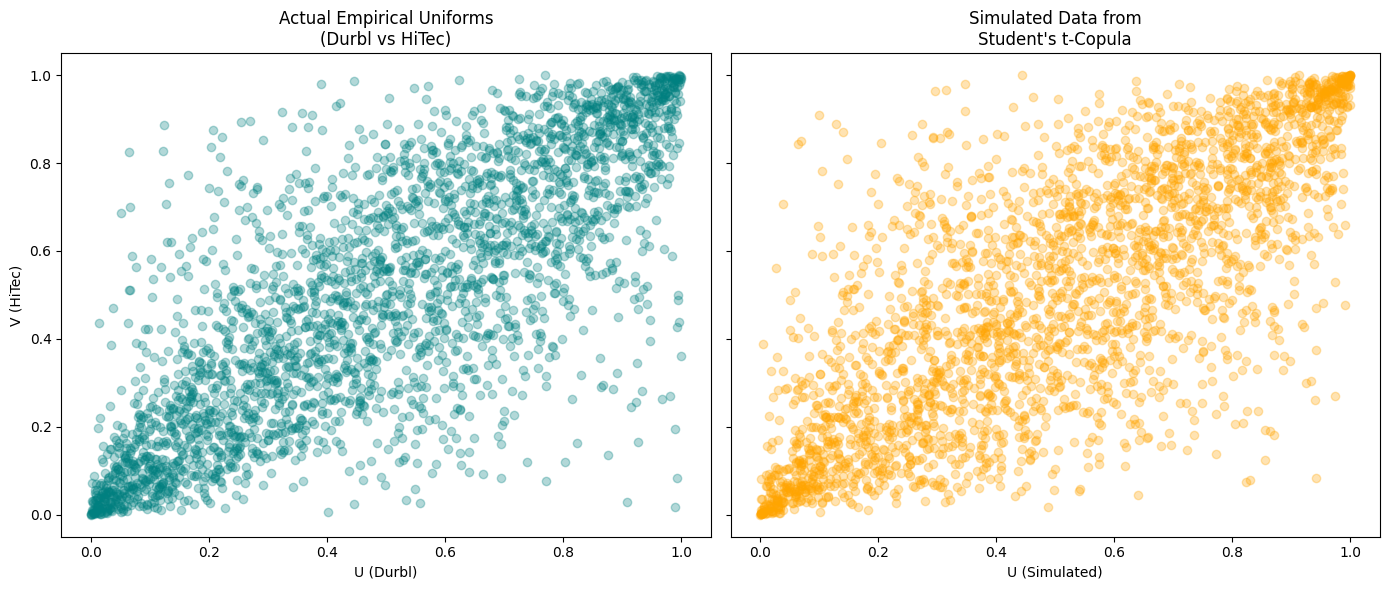

In [76]:
import matplotlib.pyplot as plt

# 1. Simulate data from the fitted Student's t-copula
sim_data = t_cop.random(len(data))

# 2. Plotting side-by-side
fig, ax = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

# Actual Data
ax[0].scatter(data[:, 0], data[:, 1], alpha=0.3, color='teal')
ax[0].set_title('Actual Empirical Uniforms\n(Durbl vs HiTec)')
ax[0].set_xlabel('U (Durbl)')
ax[0].set_ylabel('V (HiTec)')

# Simulated Data
ax[1].scatter(sim_data[:, 0], sim_data[:, 1], alpha=0.3, color='orange')
ax[1].set_title('Simulated Data from\nStudent\'s t-Copula')
ax[1].set_xlabel('U (Simulated)')

plt.tight_layout()
plt.show()

## 7. Multivariate Copula Expansion
To model the entire portfolio of 10 assets, we fit a multivariate copula. Given that the Student's t-distribution was the best fit for our bivariate case, we will fit a **Multivariate Student's t-Copula** to the empirical uniforms of all assets in `asset_list`.

In [77]:
from copulae import StudentCopula
import pandas as pd

# 1. Collect empirical uniform data for all assets
all_u_cols = [f'u_emp_{asset}' for asset in asset_list]
multi_data = df_2006_2016[all_u_cols].values

# 2. Initialize and fit the Multivariate Student-t Copula
multi_t_cop = StudentCopula(dim=len(asset_list))
multi_t_cop.fit(multi_data)

print(f"Multivariate Student-t Copula fitted across {len(asset_list)} assets.")
print(f"Estimated Degrees of Freedom (Nu): {multi_t_cop.params.df:.4f}")

# 3. Use .sigma to get the full Correlation Matrix
# .params.rho only returns the lower triangular vector (dim*(dim-1)/2)
full_corr_matrix = multi_t_cop.sigma

corr_matrix_df = pd.DataFrame(full_corr_matrix, index=asset_list, columns=asset_list)
print("\nFitted Copula Correlation Matrix (Subset):")
display(corr_matrix_df.iloc[:5, :5])

Multivariate Student-t Copula fitted across 10 assets.
Estimated Degrees of Freedom (Nu): 8.7452

Fitted Copula Correlation Matrix (Subset):


,NoDur,Durbl,Manuf,Enrgy,HiTec
NoDur,1.000000,0.701808,0.802620,0.605217,0.739400
Durbl,0.701808,1.000000,0.863832,0.646171,0.811261
Manuf,0.802620,0.863832,1.000000,0.766459,0.855689
Enrgy,0.605217,0.646171,0.766459,1.000000,0.639329
HiTec,0.739400,0.811261,0.855689,0.639329,1.000000


In [78]:
import numpy as np
import pandas as pd
import scipy.optimize as sco

def optimize_copula_portfolio(df, assets, corr_matrix, rf_col='RF'):
    """
    Optimizes the portfolio using the Copula-based correlation matrix.
    """
    # 1. Calculate historical means and volatilities for the assets
    # We use these to reconstruct the covariance matrix: Cov = Vol_diag * Corr * Vol_diag
    mean_returns = df[assets].mean()
    vols = df[assets].std()
    risk_free_rate = df[rf_col].mean()

    # 2. Reconstruct Covariance Matrix using the Copula Correlation Matrix
    # D * Corr * D
    D = np.diag(vols)
    cov_matrix = D @ corr_matrix.values @ D

    # 3. Optimization Functions
    def portfolio_stats(weights):
        weights = np.array(weights)
        port_return = np.sum(mean_returns * weights)
        port_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
        sharpe = (port_return - risk_free_rate) / port_vol
        return port_return, port_vol, sharpe

    def min_func_sharpe(weights):
        return -portfolio_stats(weights)[2]

    # 4. Constraints and Bounds
    num_assets = len(assets)
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0, 1) for _ in range(num_assets))
    initial_guess = num_assets * [1. / num_assets]

    # 5. Run Optimization
    opt_results = sco.minimize(
        min_func_sharpe,
        initial_guess,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints
    )

    # 6. Format Output to match result_capm style
    port_ret, port_vol, port_sharpe = portfolio_stats(opt_results.x)

    weights_dict = {
        asset: round(weight, 4)
        for asset, weight in zip(assets, opt_results.x)
    }

    return {
        'portfolio_return': port_ret,
        'portfolio_volatility': port_vol,
        'max_sharpe': port_sharpe,
        'optimal_weights': weights_dict
    }

# Execute optimization
result_copula_opt = optimize_copula_portfolio(df_2006_2016, asset_list, corr_matrix_df)

# Display Results
print("--- Copula-Based Portfolio Optimization ---")
print(f"Return:     {result_copula_opt['portfolio_return']:.6f}")
print(f"Volatility: {result_copula_opt['portfolio_volatility']:.6f}")
print(f"Sharpe:     {result_copula_opt['max_sharpe']:.6f}")
print("\nOptimal Weights:")
for asset, weight in result_copula_opt['optimal_weights'].items():
    if weight > 0.0001:
        print(f"{asset}: {weight*100:.2f}%")

--- Copula-Based Portfolio Optimization ---
Return:     0.047777
Volatility: 0.955551
Sharpe:     0.045653

Optimal Weights:
NoDur: 90.46%
Telcm: 1.13%
Hlth: 8.41%


# Comparing the portfolios:

In [79]:
# Prepare data for the comparison table including the Copula results
data_for_df = []

# Add Return, Volatility, Sharpe Ratio rows
data_for_df.append({
    'Metric': 'Return',
    'Standard CAPM': result_capm['portfolio_return'],
    'GARCH-CAPM': result_capm_garch['forecasted_portfolio_return'],
    'Copula-t': result_copula_opt['portfolio_return']
})
data_for_df.append({
    'Metric': 'Volatility',
    'Standard CAPM': result_capm['portfolio_volatility'],
    'GARCH-CAPM': result_capm_garch['forecasted_portfolio_volatility'],
    'Copula-t': result_copula_opt['portfolio_volatility']
})
data_for_df.append({
    'Metric': 'Sharpe Ratio',
    'Standard CAPM': result_capm['max_sharpe'],
    'GARCH-CAPM': result_capm_garch['max_sharpe'],
    'Copula-t': result_copula_opt['max_sharpe']
})

# Collect all unique assets
all_assets = sorted(list(set(result_capm['optimal_weights'].keys()) | set(result_capm_garch['optimal_weights'].keys()) | set(result_copula_opt['optimal_weights'].keys())))

# Add Optimal Weights for each asset
for asset in all_assets:
    capm_w = result_capm['optimal_weights'].get(asset, 0)
    garch_w = result_capm_garch['optimal_weights'].get(asset, 0)
    copula_w = result_copula_opt['optimal_weights'].get(asset, 0)

    # Check if any model has a significant allocation to this asset
    if capm_w > 0.0001 or garch_w > 0.0001 or copula_w > 0.0001:
        data_for_df.append({
            'Metric': f"Weight ({asset})",
            'Standard CAPM': f"{capm_w*100:.2f}%",
            'GARCH-CAPM': f"{garch_w*100:.2f}%",
            'Copula-t': f"{copula_w*100:.2f}%"
        })

# Create and display DataFrame
result_df = pd.DataFrame(data_for_df).set_index('Metric')
print("--- Comprehensive Portfolio Comparison ---")
display(result_df)

--- Comprehensive Portfolio Comparison ---


,Standard CAPM,GARCH-CAPM,Copula-t
Metric,,,
Return,0.038603,0.038396,0.047777
Volatility,1.262288,0.866752,0.955551
Sharpe Ratio,0.027292,0.044299,0.045653
Weight (Durbl),8.41%,2.04%,0.00%
Weight (Enrgy),5.72%,11.07%,0.00%
Weight (HiTec),13.57%,11.55%,0.00%
Weight (Hlth),11.09%,10.42%,8.41%
Weight (Manuf),10.21%,11.23%,0.00%
Weight (NoDur),8.70%,7.08%,90.46%
